# Diffusion Kernel Experiment — Noise Perturbation

Robustness analysis of three affinity matrix constructions under additive Gaussian noise,
within the spectral-ALC clustering pipeline.

**Affinity types compared:**
- `gaussian`  — fully connected Gaussian kernel
- `knn`       — k-nearest-neighbour Gaussian kernel
- `diffusion` — diffusion kernel (matrix exponential of k-NN affinity)

**Sections:**
- Sections 1–7: shared setup (utility functions, constructors, datasets, parameter grids)
- Section 11 helpers: NetworkX graph visualization utilities
- Section 12: Noise robustness sweep (parameter grid at each noise level)
- Section 12b: Affinity graph visualization on noise-perturbed data

Seeds: dataset generation = 42, ALC = 6.

---
## Section 1: Imports and Utility Functions

In [1]:
import sys
import os
import time
import warnings

# Add project root to path (this notebook lives in <root>/notebooks/)
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from scipy.linalg import eigh, eig, expm
from scipy.spatial.distance import cdist
from sklearn.metrics import adjusted_rand_score
from tqdm.notebook import tqdm

from clustering.alc import ALCAdapter
from data.generators import make_blobs_convex, make_rings, make_two_moons

import networkx as nx


warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

print("Imports complete.")

Imports complete.


In [2]:
# ── Utility functions ─────────────────────────────────────────────────────────

def dist_mat(X):
    """Return the pairwise Euclidean distance matrix for data matrix X."""
    return cdist(X, X, "euclidean")


def check_psd(M, name="Matrix", quiet=False):
    """
    Check whether M is symmetric and positive semi-definite.

    Parameters
    ----------
    M     : ndarray, square matrix to inspect
    name  : str, label used in the printed summary
    quiet : bool, suppress printed output when True

    Returns
    -------
    dict with keys: is_symmetric, is_psd, min_eigenvalue, n_negative_eigenvalues
    """
    is_symmetric = bool(np.allclose(M, M.T))
    eigenvalues  = np.linalg.eigvalsh(M)
    is_psd       = bool(np.all(eigenvalues >= -1e-10))
    n_neg        = int(np.sum(eigenvalues < -1e-10))

    result = {
        "is_symmetric":           is_symmetric,
        "is_psd":                 is_psd,
        "min_eigenvalue":         float(eigenvalues.min()),
        "n_negative_eigenvalues": n_neg,
    }

    if not quiet:
        print(f"{name}: symmetric={is_symmetric}, PSD={is_psd}, "
              f"min_eig={eigenvalues.min():.4e}, n_neg={n_neg}")

    return result


'''def project_to_psd(A):
    """
    Project A onto the PSD cone by clipping negative eigenvalues to zero.

    Returns the nearest PSD matrix (in Frobenius norm) to A.
    """
    vals, vecs = np.linalg.eigh(A)
    vals_clipped = np.maximum(vals, 0.0)
    A_psd = vecs @ np.diag(vals_clipped) @ vecs.T
    A_psd = (A_psd + A_psd.T) / 2   # enforce numerical symmetry
    return A_psd '''


print("Utility functions defined.")

Utility functions defined.


---
## Section 2: Affinity Matrix Constructors

All three constructors accept a precomputed pairwise distance matrix and return an affinity matrix A.
The diagonal is **kept** (not zeroed) to preserve the PSD property of the Gaussian kernel.

In [3]:
# ── Affinity constructors ──────────────────────────────────────────────────────

def affinity_gaussian(dist_matrix, sigma):
    """
    Fully connected Gaussian kernel affinity matrix.

    A[i,j] = exp(-dist[i,j]^2 / (2 * sigma^2)).
    Diagonal entries are exp(0) = 1 (self-similarity kept).
    """
    return np.exp(-dist_matrix**2 / (2.0 * sigma**2))


def affinity_knn(dist_matrix, k, sigma):
    """
    k-nearest-neighbour Gaussian affinity matrix.

    Connects each point to its k nearest neighbours with a Gaussian kernel
    weight. The mask is symmetrised via the OR rule so the graph is undirected.
    The diagonal is forced True to preserve self-similarity.

    Parameters
    ----------
    dist_matrix : ndarray (n, n)
    k           : int, number of nearest neighbours
    sigma       : float, Gaussian bandwidth
    """
    n = dist_matrix.shape[0]

    # Fallback: if k >= n-1 the graph is fully connected
    if k >= n - 1:
        return affinity_gaussian(dist_matrix, sigma)

    # Step 1: k nearest neighbours for each row (skip self at sorted index 0)
    nn_idx = np.argsort(dist_matrix, axis=1)[:, 1:k + 1]   # (n, k)

    # Step 2: build directed adjacency mask
    nn_mask = np.zeros((n, n), dtype=bool)
    rows = np.repeat(np.arange(n), k)
    nn_mask[rows, nn_idx.ravel()] = True

    # Step 3: symmetrise (OR rule → undirected graph)
    sym_mask = nn_mask | nn_mask.T

    # Step 4: keep self-similarity on the diagonal
    np.fill_diagonal(sym_mask, True)

    # Step 5: full Gaussian kernel
    W = np.exp(-dist_matrix**2 / (2.0 * sigma**2))

    # Step 6: apply mask
    return W * sym_mask


def affinity_diffusion(dist_matrix, k, sigma, t):
    """
    Diffusion kernel affinity matrix.

    Builds a k-NN Gaussian affinity A, projects onto the PSD cone, then
    computes K_t = expm(-t * A_psd) via the matrix exponential.

    Parameters
    ----------
    dist_matrix : ndarray (n, n)
    k           : int, number of nearest neighbours
    sigma       : float, Gaussian bandwidth
    t           : float, diffusion time (controls smoothing)

    Returns
    -------
    K_t : ndarray (n, n), diffusion kernel (approximately PSD)

    Note: expm is scipy.linalg.expm (true matrix exponential, not elementwise).
    """
    # Step 1: base k-NN affinity
    A_knn = affinity_knn(dist_matrix, k, sigma)

    # Step 2: project onto PSD cone
    #A_psd = project_to_psd(A_knn)

    # Step 3: diffusion kernel via matrix exponential
    K_t = expm(-t * A_knn)

    # Step 4: symmetrise for numerical precision
    K_t = (K_t + K_t.T) / 2

    # Clip small negative entries (floating-point noise from expm)
    K_t = np.maximum(K_t, 0.0)

    return K_t


print("Affinity constructors defined.")

Affinity constructors defined.


---
## Section 3: Laplacian Constructor

Three Laplacian types:
- **unnorm**: L = D − A  (symmetric, PSD when A is non-negative)
- **sym**: L = I − D^{−1/2} A D^{−1/2}  (symmetric, real eigenvalues via `eigh`)
- **rw**: L = I − D^{−1} A  (asymmetric, may need real-part extraction from `eig`)

In [4]:
def build_laplacian(A, laplacian_type):
    """
    Construct a graph Laplacian from affinity matrix A.

    Parameters
    ----------
    A              : ndarray (n, n), symmetric affinity matrix
    laplacian_type : str, one of 'unnorm', 'sym', 'rw'

    Returns
    -------
    L            : ndarray (n, n)
    d            : ndarray (n,), degree vector
    is_symmetric : bool
    """
    d = A.sum(axis=1)
    n = len(d)
    I = np.eye(n)

    if laplacian_type == "unnorm":
        D = np.diag(d)
        L = D - A
        is_symmetric = True

    elif laplacian_type == "sym":
        d_inv_sqrt = 1.0 / np.sqrt(np.maximum(d, 1e-12))
        D_inv_sqrt = np.diag(d_inv_sqrt)
        L = I - D_inv_sqrt @ A @ D_inv_sqrt
        is_symmetric = True

    elif laplacian_type == "rw":
        d_inv = 1.0 / np.maximum(d, 1e-12)
        D_inv = np.diag(d_inv)
        L = I - D_inv @ A
        is_symmetric = False

    else:
        raise ValueError(
            f"Unknown laplacian_type: {laplacian_type!r}. "
            f"Choose from 'unnorm', 'sym', 'rw'."
        )

    return L, d, is_symmetric


print("Laplacian constructor defined.")

Laplacian constructor defined.


---
## Section 4: Eigensolver and Spectral Embedding

- Symmetric Laplacians (unnorm, sym): `scipy.linalg.eigh` — real, sorted ascending, orthonormal.
- Asymmetric Laplacian (rw): `scipy.linalg.eig` — strip imaginary noise, sort manually.
- SYM Laplacian: apply Ng–Jordan–Weiss row normalisation after selecting eigenvectors.

In [5]:
def spectral_embedding(L, r, is_symmetric, laplacian_type):
    """
    Compute the r-dimensional spectral embedding of Laplacian L.

    Parameters
    ----------
    L              : ndarray (n, n)
    r              : int, number of eigenvectors to retain
    is_symmetric   : bool, True → eigh; False → eig with real-part extraction
    laplacian_type : str, 'sym' triggers NJW row normalisation

    Returns
    -------
    U           : ndarray (n, r), spectral embedding
    eigenvalues : ndarray (r,), ascending eigenvalues
    """
    if is_symmetric:
        # eigh: guaranteed real, sorted ascending, orthonormal eigenvectors
        eigenvalues, eigenvectors = eigh(L)
    else:
        # eig: may return complex — strip imaginary noise then sort
        eigenvalues_c, eigenvectors_c = eig(L)
        eigenvalues  = eigenvalues_c.real
        eigenvectors = eigenvectors_c.real
        sort_idx     = np.argsort(eigenvalues)
        eigenvalues  = eigenvalues[sort_idx]
        eigenvectors = eigenvectors[:, sort_idx]

    # Select first r eigenvectors and eigenvalues (smallest eigenvalues)
    U = eigenvectors[:, :r]
    lambdas = eigenvalues[:r]

    # Ng-Jordan-Weiss row normalisation for the SYM Laplacian
    if laplacian_type == "sym":
        row_norms = np.sqrt(np.sum(U**2, axis=1, keepdims=True)) # check this 
        U = U / np.maximum(row_norms, 1e-12)

    return U, lambdas


print("spectral_embedding defined.")

spectral_embedding defined.


---
## Section 5: Single Experiment Runner

`run_single` chains all steps for one configuration: Laplacian → embedding → ALC → ARI.

**ALC note:** `ALCAdapter.fit_predict` expects an (n × n) correlation matrix directly —
it does **not** compute `corrcoef` internally. We call `np.corrcoef(U)` here before passing
to ALC. Near-constant eigenvectors (eigenvalue ≈ 0, zero variance → NaN in corrcoef) are
filtered out before that step.

In [6]:
def run_single(A, laplacian_type, r, y_true, seed=6):
    """
    Run one full spectral-ALC experiment for a given affinity matrix.

    Parameters
    ----------
    A              : ndarray (n, n), affinity matrix
    laplacian_type : str, 'unnorm' | 'sym' | 'rw'
    r              : int, embedding dimension
    y_true         : ndarray (n,), ground-truth cluster labels
    seed           : int, random seed for ALC

    Returns
    -------
    dict: ari, n_clusters_found, delta_k, spectral_gap,
          laplacian_is_psd, laplacian_min_eigenvalue, labels
    """
    q = len(np.unique(y_true))   # ground-truth number of clusters

    # Step 1: build Laplacian
    L, d, is_sym = build_laplacian(A, laplacian_type)

    # Step 2: PSD check on Laplacian (symmetric Laplacians only)
    if is_sym:
        lap_psd_info = check_psd(L, name=f"L_{laplacian_type}", quiet=True)
        lap_is_psd   = lap_psd_info["is_psd"]
        lap_min_eig  = lap_psd_info["min_eigenvalue"]
    else:
        lap_is_psd  = "N/A"
        lap_min_eig = np.nan

    # Step 3: spectral embedding
    # Fetch r+1 eigenvectors so that after filtering the constant eigenvector
    # (eigenvalue ≈ 0, near-zero variance → NaN in corrcoef) we still have r valid columns.
    U, eigenvalues = spectral_embedding(L, r, is_sym, laplacian_type)

    # Step 4: cluster with ALC
    # ALCAdapter.fit_predict takes an (n, n) correlation matrix — not the raw embedding.
    np.random.seed(seed)
    alc    = ALCAdapter()
    # Reconstruct: Phi_q @ Lambda_q @ Phi_q^T
    R_hat = U @ np.diag(1 - eigenvalues) @ U.T

    # Rescale to unit diagonal — restore valid correlation matrix
    diag = np.sqrt(np.diag(R_hat))
    diag = np.where(diag == 0, 1, diag)  # guard against zero diagonal
    R_hat = R_hat / np.outer(diag, diag)

    # Clip to [-1, 1] to correct floating point violations
    R_hat = np.clip(R_hat, -1, 1)     
    
    labels = alc.fit_predict(R_hat, cn=None) # cn=None → ALC infers cluster count

    # Step 5: evaluate
    ari              = adjusted_rand_score(y_true, labels)
    n_clusters_found = int(len(np.unique(labels)))

    # Step 6: spectral gap (λ_q − λ_{q-1}, 0-indexed)
    if len(eigenvalues) > q:
        spectral_gap = float(eigenvalues[q] - eigenvalues[q - 1])
    else:
        spectral_gap = np.nan

    return {
        "ari":                      ari,
        "n_clusters_found":         n_clusters_found,
        "delta_k":                  abs(n_clusters_found - q),
        "spectral_gap":             spectral_gap,
        "laplacian_is_psd":         lap_is_psd,
        "laplacian_min_eigenvalue": lap_min_eig,
        "labels":                   labels,
        "eigenvectors":             U,
        "eigenvalues":              eigenvalues,
        "correlation_mat":          R_hat,
    }


print("run_single defined.")

run_single defined.


---
## Section 6: Dataset Generation

| Dataset | Generator           | N   | Clusters | Dimensionality |
|---------|---------------------|-----|----------|----------------|
| blobs   | `make_blobs_convex` | 1200 | 7        | 5000           |
| circles | `make_rings`        | 1200 | 3        | 2              |
| moons   | `make_two_moons`    | 1200| 2        | 2              |

Datasets generated:
       blobs: X=(500, 5000), classes=[0 1 2 3 4 5 6], n_clusters=7
     circles: X=(500, 2), classes=[1 2 3], n_clusters=3
       moons: X=(500, 2), classes=[0 1], n_clusters=2


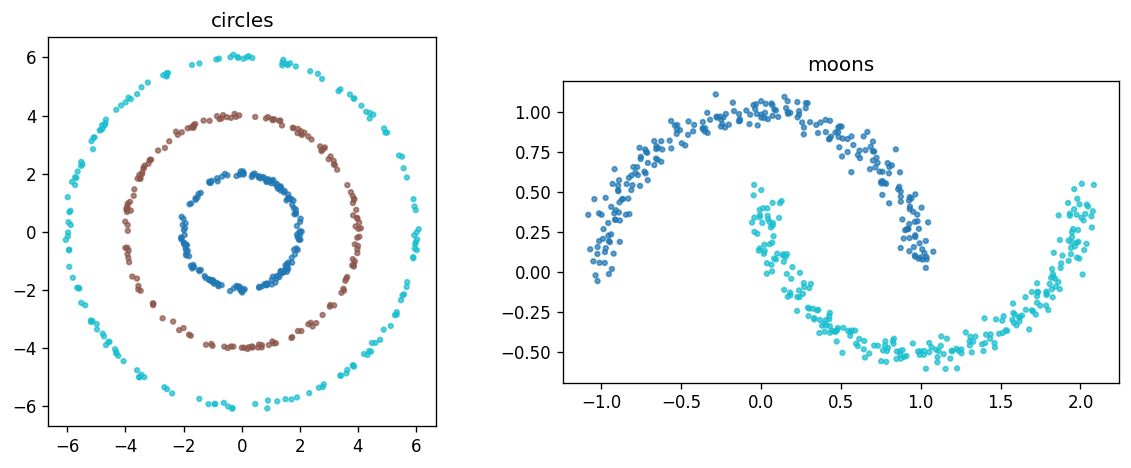

In [7]:
# ── Blobs: high-dimensional Gaussian clusters ─────────────────────────────────
X_blobs, y_blobs = make_blobs_convex(N=500, num_clusters=7, n_features=5000, seed=42)
ds_blobs = {"name": "blobs", "X": X_blobs, "y": y_blobs, "n_clusters": 7}

# ── Circles: concentric rings ─────────────────────────────────────────────────
X_circles, y_circles = make_rings(n_points=500, n_circles=3, noise_std=0.05, seed=42)
ds_circles = {"name": "circles", "X": X_circles, "y": y_circles, "n_clusters": 3}

# ── Moons: two interleaved half-circles ───────────────────────────────────────
X_moons, y_moons = make_two_moons(n_samples=500, noise=0.05, seed=42)
ds_moons = {"name": "moons", "X": X_moons, "y": y_moons, "n_clusters": 2}

datasets = [ds_blobs, ds_circles, ds_moons]

print("Datasets generated:")
for ds in datasets:
    print(f"  {ds['name']:>10s}: X={ds['X'].shape}, "
          f"classes={np.unique(ds['y'])}, n_clusters={ds['n_clusters']}")

# Quick scatter for the 2-D datasets
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, ds in zip(axes, [ds_circles, ds_moons]):
    ax.scatter(ds["X"][:, 0], ds["X"][:, 1],
               c=ds["y"], cmap="tab10", s=8, alpha=0.7)
    ax.set_title(ds["name"])
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

---
## Section 6b: Pipeline Sanity Check

One k-NN run per dataset at fixed, reasonable parameters to confirm the end-to-end
pipeline (affinity → Laplacian → embedding → ALC → ARI) is working before the full sweep.

In [8]:
# ── Sanity check: one run per dataset ────────────────────────────────────────
# k-NN affinity, unnormalised Laplacian, r = true number of clusters.
# Parameters chosen from known-good region; expected ARI = 1.0 on all three.

sanity_configs = [
    {"ds": ds_blobs,   "sigma": 10,   "k": 10,  "r": 7},
    {"ds": ds_circles, "sigma": 0.2,  "k": 10, "r": 3},
    {"ds": ds_moons,   "sigma": 0.1,  "k": 10, "r": 2},
]

print(f"{'Dataset':>10s}  {'ARI':>6s}  {'k_found':>8s}  {'k_true':>7s}")
print("-" * 38)
for cfg in sanity_configs:
    ds    = cfg["ds"]
    D     = dist_mat(ds["X"])
    A     = affinity_knn(D, cfg["k"], cfg["sigma"])
    out   = run_single(A, "sym", cfg["r"], ds["y"])
    q     = ds["n_clusters"]
    print(f"{ds['name']:>10s}  {out['ari']:6.3f}  {out['n_clusters_found']:8d}  {q:7d}")


   Dataset     ARI   k_found   k_true
--------------------------------------
     blobs   1.000         7        7
   circles   1.000         3        3
     moons   1.000         2        2


---
## Section 7: Parameter Grids

All three affinity types share the same `sigma_values` grid, allowing the bandwidth
parameter to be assessed independently of the structural parameter `k`.
- **Gaussian**: sweeps `(sigma)`.
- **k-NN**: sweeps `(sigma, k)` — the full Cartesian product.
- **Diffusion**: sweeps `(sigma, k, t)` — the full Cartesian product.

In [9]:
param_grids = {
    "blobs": {
        "sigma_values":    [10, 25],
        "k_values":        [5, 10, 15],
        "t_values":        [1.0, 5.0, 10.0],
        "r_values":        [7, 10],
        "laplacian_types": ["unnorm", "sym", "rw"],
    },
    "circles": {
        "sigma_values":    [0.1, 0.25],
        "k_values":        [5, 10, 15],
        "t_values":        [1.0, 5.0, 10.0],
        "r_values":        [3, 5],
        "laplacian_types": ["unnorm", "sym", "rw"],
    },
    "moons": {
        "sigma_values":    [0.1, 0.25],
        "k_values":        [5, 10, 15],
        "t_values":        [1.0, 5.0, 10.0],
        "r_values":        [2, 4],
        "laplacian_types": ["unnorm", "sym", "rw"],
    },
}

# Configuration count summary
# k-NN sweeps (sigma, k); diffusion sweeps (sigma, k, t).
grand_total = 0
for ds_name, g in param_grids.items():
    n_lap   = len(g["laplacian_types"])
    n_r     = len(g["r_values"])
    n_sigma = len(g["sigma_values"])
    n_gauss = n_sigma * n_lap * n_r
    n_knn   = len(g["k_values"]) * n_sigma * n_lap * n_r
    n_diff  = len(g["k_values"]) * n_sigma * len(g["t_values"]) * n_lap * n_r
    ds_total = n_gauss + n_knn + n_diff
    grand_total += ds_total
    print(f"{ds_name:>10s}: gaussian={n_gauss:4d}  knn={n_knn:5d}  "
          f"diffusion={n_diff:5d}  →  {ds_total:5d} total")

print(f"\nTotal configurations across all datasets: {grand_total}")

     blobs: gaussian=  12  knn=   36  diffusion=  108  →    156 total
   circles: gaussian=  12  knn=   36  diffusion=  108  →    156 total
     moons: gaussian=  12  knn=   36  diffusion=  108  →    156 total

Total configurations across all datasets: 468


---
## Section 11: Affinity Graph Visualization (NetworkX)

Overlay each affinity graph on the 2D clustering solution produced by the same ALC pipeline used throughout this notebook.

- **Nodes** sit at their actual 2D coordinates, colored by ALC-assigned cluster
- **Edges** show the affinity weights; only edges above a `threshold` are drawn (keeps dense graphs readable)
- **Z-order**: edges drawn first (behind), nodes on top
- We subsample the 2D datasets to ≤ 200 points per call so NetworkX renders quickly

In [10]:
# Install NetworkX if not already present
import importlib, subprocess, sys as _sys
if importlib.util.find_spec("networkx") is None:
    subprocess.check_call([_sys.executable, "-m", "pip", "install", "networkx", "-q"])

import networkx as nx
print(f"networkx {nx.__version__} ready.")

networkx 3.6.1 ready.


In [11]:
def plot_affinity_graph(
    coords,
    labels,
    affinity,
    threshold=0.0,
    title="",
    ax=None,
    figsize=(7, 6),
    edge_alpha=0.20,
    edge_color="#777777",
    node_size=40,
    node_alpha=0.85,
):
    """
    Overlay an affinity graph on a 2D clustering solution.

    Parameters
    ----------
    coords    : (N, 2) array — node positions (actual 2D coordinates)
    labels    : (N,) integer array — ALC cluster assignments (for node colors)
    affinity  : (N, N) affinity matrix (dense ndarray or scipy sparse)
    threshold : float — only draw edges with weight > threshold
    title     : str — plot title
    ax        : matplotlib Axes to draw into; creates a new figure when None
    figsize   : tuple — figure size when ax is None
    edge_alpha: float — edge opacity (0 invisible → 1 opaque)
    edge_color: str   — edge color
    node_size : int   — scatter marker area
    node_alpha: float — node opacity

    Returns
    -------
    fig, ax
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    # Handle scipy sparse input
    A = affinity.toarray() if hasattr(affinity, "toarray") else np.asarray(affinity)

    # Build NetworkX graph from upper triangle above threshold
    G = nx.Graph()
    n = len(coords)
    G.add_nodes_from(range(n))
    tri_mask = np.triu(np.ones((n, n), dtype=bool), k=1)
    rows_e, cols_e = np.where((A > threshold) & tri_mask)
    for r, c in zip(rows_e, cols_e):
        G.add_edge(int(r), int(c))

    pos = {i: (float(coords[i, 0]), float(coords[i, 1])) for i in range(n)}

    # Cluster → color mapping
    unique_labels = np.unique(labels)
    cmap          = plt.cm.tab10
    color_map     = {int(l): cmap(i / max(len(unique_labels), 1))
                     for i, l in enumerate(unique_labels)}
    node_colors   = [color_map[int(labels[i])] for i in range(n)]

    # ── Draw edges first (z-order: behind nodes) ──────────────────────────────
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=edge_alpha,
                           edge_color=edge_color, width=0.6)

    # ── Draw nodes on top ─────────────────────────────────────────────────────
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=node_size, alpha=node_alpha)

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_handles = [
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=color_map[int(l)], markersize=8,
                   label=f"Cluster {l}")
        for l in unique_labels
    ]
    ax.legend(handles=legend_handles, loc="best", fontsize=8, framealpha=0.8)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
    ax.grid(True, alpha=0.2)
    ax.set_aspect("equal", adjustable="datalim")

    return fig, ax


print("plot_affinity_graph ready.")

plot_affinity_graph ready.


### 11a — Visualization datasets

Subsample to 200 points so NetworkX renders quickly. Distance matrices are recomputed on the subsample.

In [12]:
N_VIZ = 200
rng   = np.random.default_rng(42)

idx_c         = rng.choice(len(ds_circles["y"]), size=N_VIZ, replace=False)
X_viz_c       = ds_circles["X"][idx_c]
y_viz_c       = ds_circles["y"][idx_c]
D_viz_c       = dist_mat(X_viz_c)

idx_m         = rng.choice(len(ds_moons["y"]), size=N_VIZ, replace=False)
X_viz_m       = ds_moons["X"][idx_m]
y_viz_m       = ds_moons["y"][idx_m]
D_viz_m       = dist_mat(X_viz_m)

print(f"circles subsample: {X_viz_c.shape},  moons subsample: {X_viz_m.shape}")

circles subsample: (200, 2),  moons subsample: (200, 2)


---
## Section 12: Noise Robustness Experiments

The full parameter grid from Section 7 is swept independently at each noise level.
Additive Gaussian noise with increasing σ is applied to the raw features via `add_gaussian_noise`.

- **Table N1** — best parameters and ARI at every (noise level, dataset, affinity).
- **Plot N1** — best achievable ARI vs σ (maximised over all parameters).
- **Plot N2** — |k_found − k_true| at the best-ARI configuration vs σ.

In [13]:
from data.generators import add_gaussian_noise

# Per-dataset noise levels — blobs live in 5000-D so meaningful perturbations
# are much larger in absolute scale than for the 2-D datasets.
noise_levels_by_ds = {
    "blobs":   [5, 25],
    "circles": [0.1, 0.5],
    "moons":   [0.1,0.5],
}

noise_grand_total = sum(
    len(noise_levels_by_ds[ds["name"]]) * (
        len(param_grids[ds["name"]]["sigma_values"]) * len(param_grids[ds["name"]]["laplacian_types"]) * len(param_grids[ds["name"]]["r_values"])
        + len(param_grids[ds["name"]]["k_values"]) * len(param_grids[ds["name"]]["sigma_values"]) * len(param_grids[ds["name"]]["laplacian_types"]) * len(param_grids[ds["name"]]["r_values"])
        + len(param_grids[ds["name"]]["k_values"]) * len(param_grids[ds["name"]]["sigma_values"]) * len(param_grids[ds["name"]]["t_values"]) * len(param_grids[ds["name"]]["laplacian_types"]) * len(param_grids[ds["name"]]["r_values"])
    )
    for ds in datasets
)
print(f"Noise sweep: {noise_grand_total} total runs across all datasets and noise levels")
for ds in datasets:
    name    = ds["name"]
    g       = param_grids[name]
    n_sigma = len(g["sigma_values"])
    n_lap   = len(g["laplacian_types"])
    n_r     = len(g["r_values"])
    n_per_ds = (n_sigma * n_lap * n_r
                + len(g["k_values"]) * n_sigma * n_lap * n_r
                + len(g["k_values"]) * n_sigma * len(g["t_values"]) * n_lap * n_r)
    print(f"  {name:>10s}: noise levels={noise_levels_by_ds[name]},  "
          f"{len(noise_levels_by_ds[name])} × {n_per_ds} = {len(noise_levels_by_ds[name]) * n_per_ds} runs")

Noise sweep: 936 total runs across all datasets and noise levels
       blobs: noise levels=[5, 25],  2 × 156 = 312 runs
     circles: noise levels=[0.1, 0.5],  2 × 156 = 312 runs
       moons: noise levels=[0.1, 0.5],  2 × 156 = 312 runs


In [14]:
noise_results = []

base_X = {"blobs": X_blobs, "circles": X_circles, "moons": X_moons}
base_y = {"blobs": y_blobs, "circles": y_circles, "moons": y_moons}

def _record(noise_std, name, aff, sigma, k, t, r, lap, outcome):
    base = {"noise_std": noise_std, "dataset": name, "affinity": aff,
            "sigma": sigma, "k": k, "t": t, "rank_r": r, "laplacian": lap}
    if isinstance(outcome, Exception):
        noise_results.append({**base, "ari": np.nan, "n_clusters_found": np.nan,
                               "delta_k": np.nan, "spectral_gap": np.nan,
                               "laplacian_is_psd": np.nan,
                               "laplacian_min_eigenvalue": np.nan,
                               "error": str(outcome)})
    else:
        noise_results.append({**base, **outcome})

for ds in tqdm(datasets, desc="Datasets"):
    name   = ds["name"]
    y      = base_y[name]
    g      = param_grids[name]
    X_base = base_X[name]

    for noise_std in tqdm(noise_levels_by_ds[name], desc=name, leave=False):
        X_noisy = add_gaussian_noise(X_base, noise_std=noise_std, seed=0)
        D = dist_mat(X_noisy)

        sigma_values    = g["sigma_values"]
        k_values        = g["k_values"]
        t_values        = g["t_values"]
        r_values        = g["r_values"]
        laplacian_types = g["laplacian_types"]

        # ── Gaussian ──────────────────────────────────────────────────────────
        for sigma in sigma_values:
            A = affinity_gaussian(D, sigma)
            for lap in laplacian_types:
                for r in r_values:
                    try:
                        _record(noise_std, name, "gaussian", sigma, "N/A", "N/A", r, lap,
                                run_single(A, lap, r, y))
                    except Exception as e:
                        _record(noise_std, name, "gaussian", sigma, "N/A", "N/A", r, lap, e)

        # ── k-NN ──────────────────────────────────────────────────────────────
        for k in k_values:
            for sigma in sigma_values:
                A = affinity_knn(D, k, sigma)
                for lap in laplacian_types:
                    for r in r_values:
                        try:
                            _record(noise_std, name, "knn", sigma, k, "N/A", r, lap,
                                    run_single(A, lap, r, y))
                        except Exception as e:
                            _record(noise_std, name, "knn", sigma, k, "N/A", r, lap, e)

        # ── Diffusion ─────────────────────────────────────────────────────────
        for k in k_values:
            for sigma in sigma_values:
                for t in t_values:
                    A = affinity_diffusion(D, k, sigma, t)
                    for lap in laplacian_types:
                        for r in r_values:
                            try:
                                _record(noise_std, name, "diffusion", sigma, k, t, r, lap,
                                        run_single(A, lap, r, y))
                            except Exception as e:
                                _record(noise_std, name, "diffusion", sigma, k, t, r, lap, e)

df_noise = pd.DataFrame(noise_results)
print(f"\nNoise sweep complete: {len(df_noise)} rows")
df_noise.head()

Datasets:   0%|          | 0/3 [00:00<?, ?it/s]

blobs:   0%|          | 0/2 [00:00<?, ?it/s]

circles:   0%|          | 0/2 [00:00<?, ?it/s]

moons:   0%|          | 0/2 [00:00<?, ?it/s]


Noise sweep complete: 936 rows


,noise_std,dataset,affinity,sigma,k,t,rank_r,laplacian,ari,n_clusters_found,delta_k,spectral_gap,laplacian_is_psd,laplacian_min_eigenvalue,labels,eigenvectors,eigenvalues,correlation_mat
0,5.0,blobs,gaussian,10.0,N/A,N/A,7,unnorm,0.0,500,493,NaN,True,0.0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 1....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,5.0,blobs,gaussian,10.0,N/A,N/A,10,unnorm,0.0,500,493,0.0,True,0.0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,5.0,blobs,gaussian,10.0,N/A,N/A,7,sym,0.0,500,493,NaN,True,0.0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 1....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
3,5.0,blobs,gaussian,10.0,N/A,N/A,10,sym,0.0,500,493,0.0,True,0.0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
4,5.0,blobs,gaussian,10.0,N/A,N/A,7,rw,0.0,500,493,NaN,N/A,NaN,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


TABLE N1: Best parameters and ARI at each noise level

=== BLOBS ===

  gaussian:
    noise_std=5: ARI=0.537  [σ=25, r=10, lap=unnorm]
    noise_std=25: ARI=0.000  [σ=10, r=7, lap=unnorm]

  knn:
    noise_std=5: ARI=0.435  [σ=25, k=15, r=10, lap=unnorm]
    noise_std=25: ARI=0.000  [σ=10, k=5, r=7, lap=unnorm]

  diffusion:
    noise_std=5: ARI=0.568  [σ=25, k=5, t=5, r=10, lap=sym]
    noise_std=25: ARI=0.000  [σ=10, k=5, t=1, r=7, lap=unnorm]

=== CIRCLES ===

  gaussian:
    noise_std=0.1: ARI=1.000  [σ=0.25, r=3, lap=unnorm]
    noise_std=0.5: ARI=0.133  [σ=0.25, r=5, lap=unnorm]

  knn:
    noise_std=0.1: ARI=1.000  [σ=0.25, k=10, r=3, lap=unnorm]
    noise_std=0.5: ARI=0.132  [σ=0.25, k=15, r=5, lap=rw]

  diffusion:
    noise_std=0.1: ARI=1.000  [σ=0.25, k=10, t=1, r=3, lap=unnorm]
    noise_std=0.5: ARI=0.212  [σ=0.25, k=15, t=10, r=3, lap=sym]

=== MOONS ===

  gaussian:
    noise_std=0.1: ARI=0.142  [σ=0.1, r=2, lap=sym]
    noise_std=0.5: ARI=0.171  [σ=0.25, r=2, lap=sym]



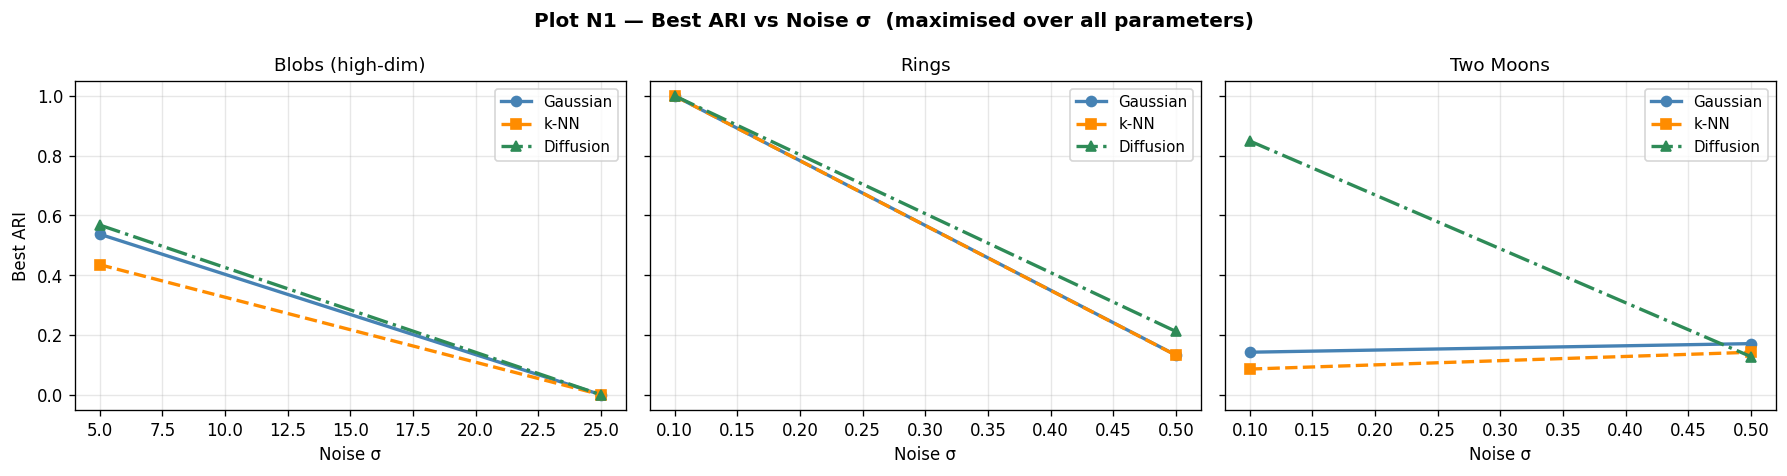

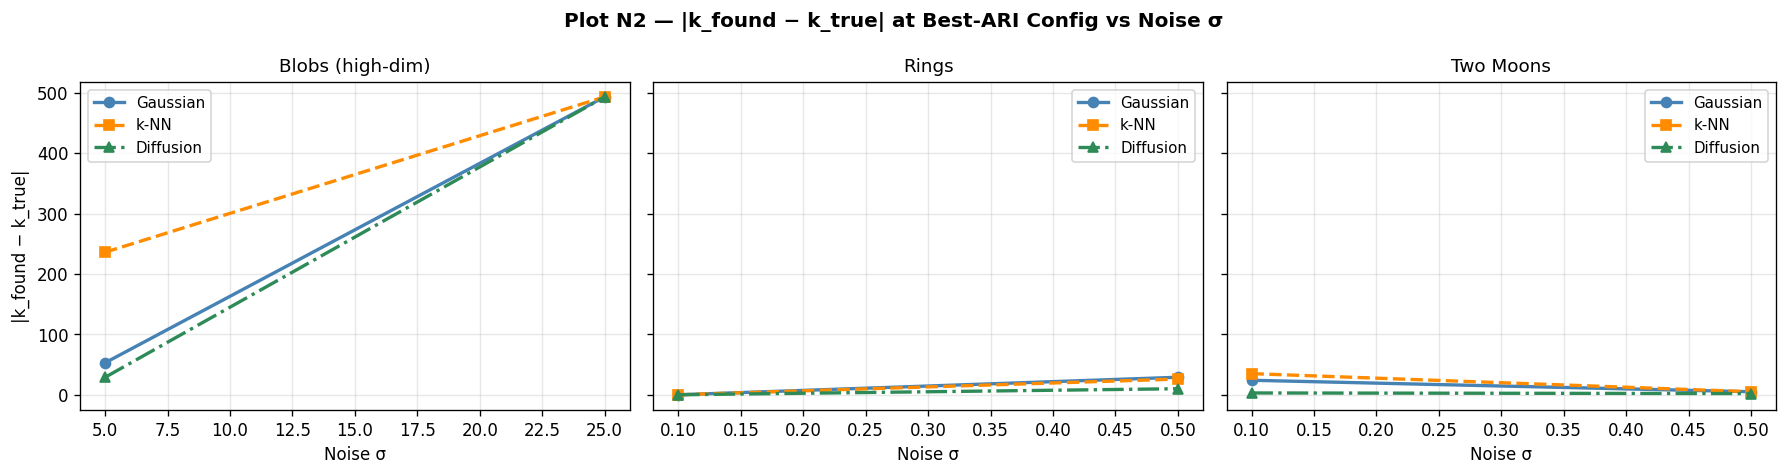

In [15]:
noise_aff_styles = {
    "gaussian":  dict(color="steelblue",  marker="o", linestyle="-",  label="Gaussian"),
    "knn":       dict(color="darkorange", marker="s", linestyle="--", label="k-NN"),
    "diffusion": dict(color="seagreen",   marker="^", linestyle="-.", label="Diffusion"),
}
ds_titles = {"blobs": "Blobs (high-dim)", "circles": "Rings", "moons": "Two Moons"}

# ── Table N1: Best params at each noise level ─────────────────────────────────
print("TABLE N1: Best parameters and ARI at each noise level")
print("=" * 72)
for ds_name in ["blobs", "circles", "moons"]:
    print(f"\n=== {ds_name.upper()} ===")
    for aff in ["gaussian", "knn", "diffusion"]:
        sub = df_noise[(df_noise["dataset"] == ds_name) & (df_noise["affinity"] == aff)]
        if sub.empty or sub["ari"].isna().all():
            continue
        print(f"\n  {aff}:")
        for ns in noise_levels_by_ds[ds_name]:
            lvl = sub[sub["noise_std"] == ns].dropna(subset=["ari"])
            if lvl.empty:
                continue
            best = lvl.loc[lvl["ari"].idxmax()]
            k_str = f"k={int(best['k'])}" if best.get("k") not in ("N/A", None) else ""
            t_str = f"t={best['t']:.2g}"  if best.get("t") not in ("N/A", None) else ""
            parts = [f"σ={best['sigma']:.3g}", k_str, t_str,
                     f"r={int(best['rank_r'])}", f"lap={best['laplacian']}"]
            print(f"    noise_std={ns}: ARI={best['ari']:.3f}  "
                  f"[{', '.join(p for p in parts if p)}]")

# ── Plot N1: Best ARI vs noise σ ──────────────────────────────────────────────
best_per_noise = (df_noise.dropna(subset=["ari"])
                          .groupby(["noise_std", "dataset", "affinity"])["ari"]
                          .max()
                          .reset_index())

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Plot N1 — Best ARI vs Noise σ  (maximised over all parameters)",
             fontsize=12, fontweight="bold")

for ax, ds_name in zip(axes, ["blobs", "circles", "moons"]):
    for aff, style in noise_aff_styles.items():
        sub = best_per_noise[(best_per_noise["dataset"] == ds_name) &
                             (best_per_noise["affinity"] == aff)]
        if sub.empty:
            continue
        ax.plot(sub["noise_std"], sub["ari"], **style, linewidth=2, markersize=6)
    ax.set_title(ds_titles[ds_name], fontsize=11)
    ax.set_xlabel("Noise σ", fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel("Best ARI", fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Plot N2: |delta_k| at best-ARI config vs noise σ ─────────────────────────
best_idx  = (df_noise.dropna(subset=["ari"])
                     .groupby(["noise_std", "dataset", "affinity"])["ari"]
                     .idxmax())
best_rows = df_noise.loc[best_idx].reset_index(drop=True)

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig2.suptitle("Plot N2 — |k_found − k_true| at Best-ARI Config vs Noise σ",
              fontsize=12, fontweight="bold")

for ax, ds_name in zip(axes2, ["blobs", "circles", "moons"]):
    for aff, style in noise_aff_styles.items():
        sub = best_rows[(best_rows["dataset"] == ds_name) &
                        (best_rows["affinity"] == aff)]
        if sub.empty:
            continue
        ax.plot(sub["noise_std"], sub["delta_k"], **style, linewidth=2, markersize=6)
    ax.set_title(ds_titles[ds_name], fontsize=11)
    ax.set_xlabel("Noise σ", fontsize=10)
    if ax is axes2[0]:
        ax.set_ylabel("|k_found − k_true|", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [16]:
noise_output_path = "diffusion_kernel_noise_results_v3.csv"
df_noise.to_csv(noise_output_path, index=False)
print(f"Noise results saved: {df_noise.shape[0]} rows → {noise_output_path}")

Noise results saved: 936 rows → diffusion_kernel_noise_results_v3.csv


---
## Section 12b: Affinity Graph Visualization on Noise-Perturbed Data

Repeating the Section 11 NetworkX overlays on noise-perturbed versions of the 2-D datasets (Circles and Moons). Blobs are omitted here as they are not 2-D.

- **Nodes** sit at their noisy 2D coordinates, colored by ALC-assigned cluster
- **Edges** reflect the affinity computed on the noisy distances
- **Section 12b-b** shows all three affinity types at each noise level (2 × 3 grid per noise level)
- **Section 12b-c** shows how each affinity method degrades across noise levels (one figure per method)

### 12b-a — Noisy visualization subsamples

Additive Gaussian noise (matching Section 12 levels) applied to the full 2-D datasets; the same subsample indices as Section 11a are reused so cluster proportions are comparable.

In [17]:
N_VIZ_NOISY  = 500
noise_levels_2d = [0.1, 0.25, 0.5]

# Reuse the same subsample indices as Section 11a for comparability
viz_configs_noisy = [
    ("Circles", "circles", 0.2, 3, idx_c, X_circles, y_circles),
    ("Moons",   "moons",   0.1, 2, idx_m, X_moons,   y_moons),
]

noisy_viz = {}  # keyed by (ds_name, noise_std)

for noise_std in noise_levels_2d:
    for ds_label, ds_name, sigma, r, idx_viz, X_base, y_base in viz_configs_noisy:
        X_noisy_full = add_gaussian_noise(X_base, noise_std=noise_std, seed=0)
        X_sub        = X_noisy_full[idx_viz]
        y_sub        = y_base[idx_viz]
        D_sub        = dist_mat(X_sub)
        noisy_viz[(ds_name, noise_std)] = {"X": X_sub, "y": y_sub, "D": D_sub}

# Strip the extra columns for the loop variables used in 12b-b / 12b-c
viz_configs_noisy = [(ds_label, ds_name, sigma, r)
                     for ds_label, ds_name, sigma, r, *_ in viz_configs_noisy]

print("Noisy subsamples ready:")
for (ds_name, ns), v in noisy_viz.items():
    print(f"  ({ds_name}, noise σ={ns}): X={v['X'].shape}")

Noisy subsamples ready:
  (circles, noise σ=0.1): X=(200, 2)
  (moons, noise σ=0.1): X=(200, 2)
  (circles, noise σ=0.25): X=(200, 2)
  (moons, noise σ=0.25): X=(200, 2)
  (circles, noise σ=0.5): X=(200, 2)
  (moons, noise σ=0.5): X=(200, 2)


### 12b-b — All three affinity methods at each noise level

One figure per noise level (following Section 11g layout): 2 rows (Circles, Moons) × 3 columns (k-NN, Gaussian, Diffusion). Same parameters as Section 11g: k=10, t=1.0.

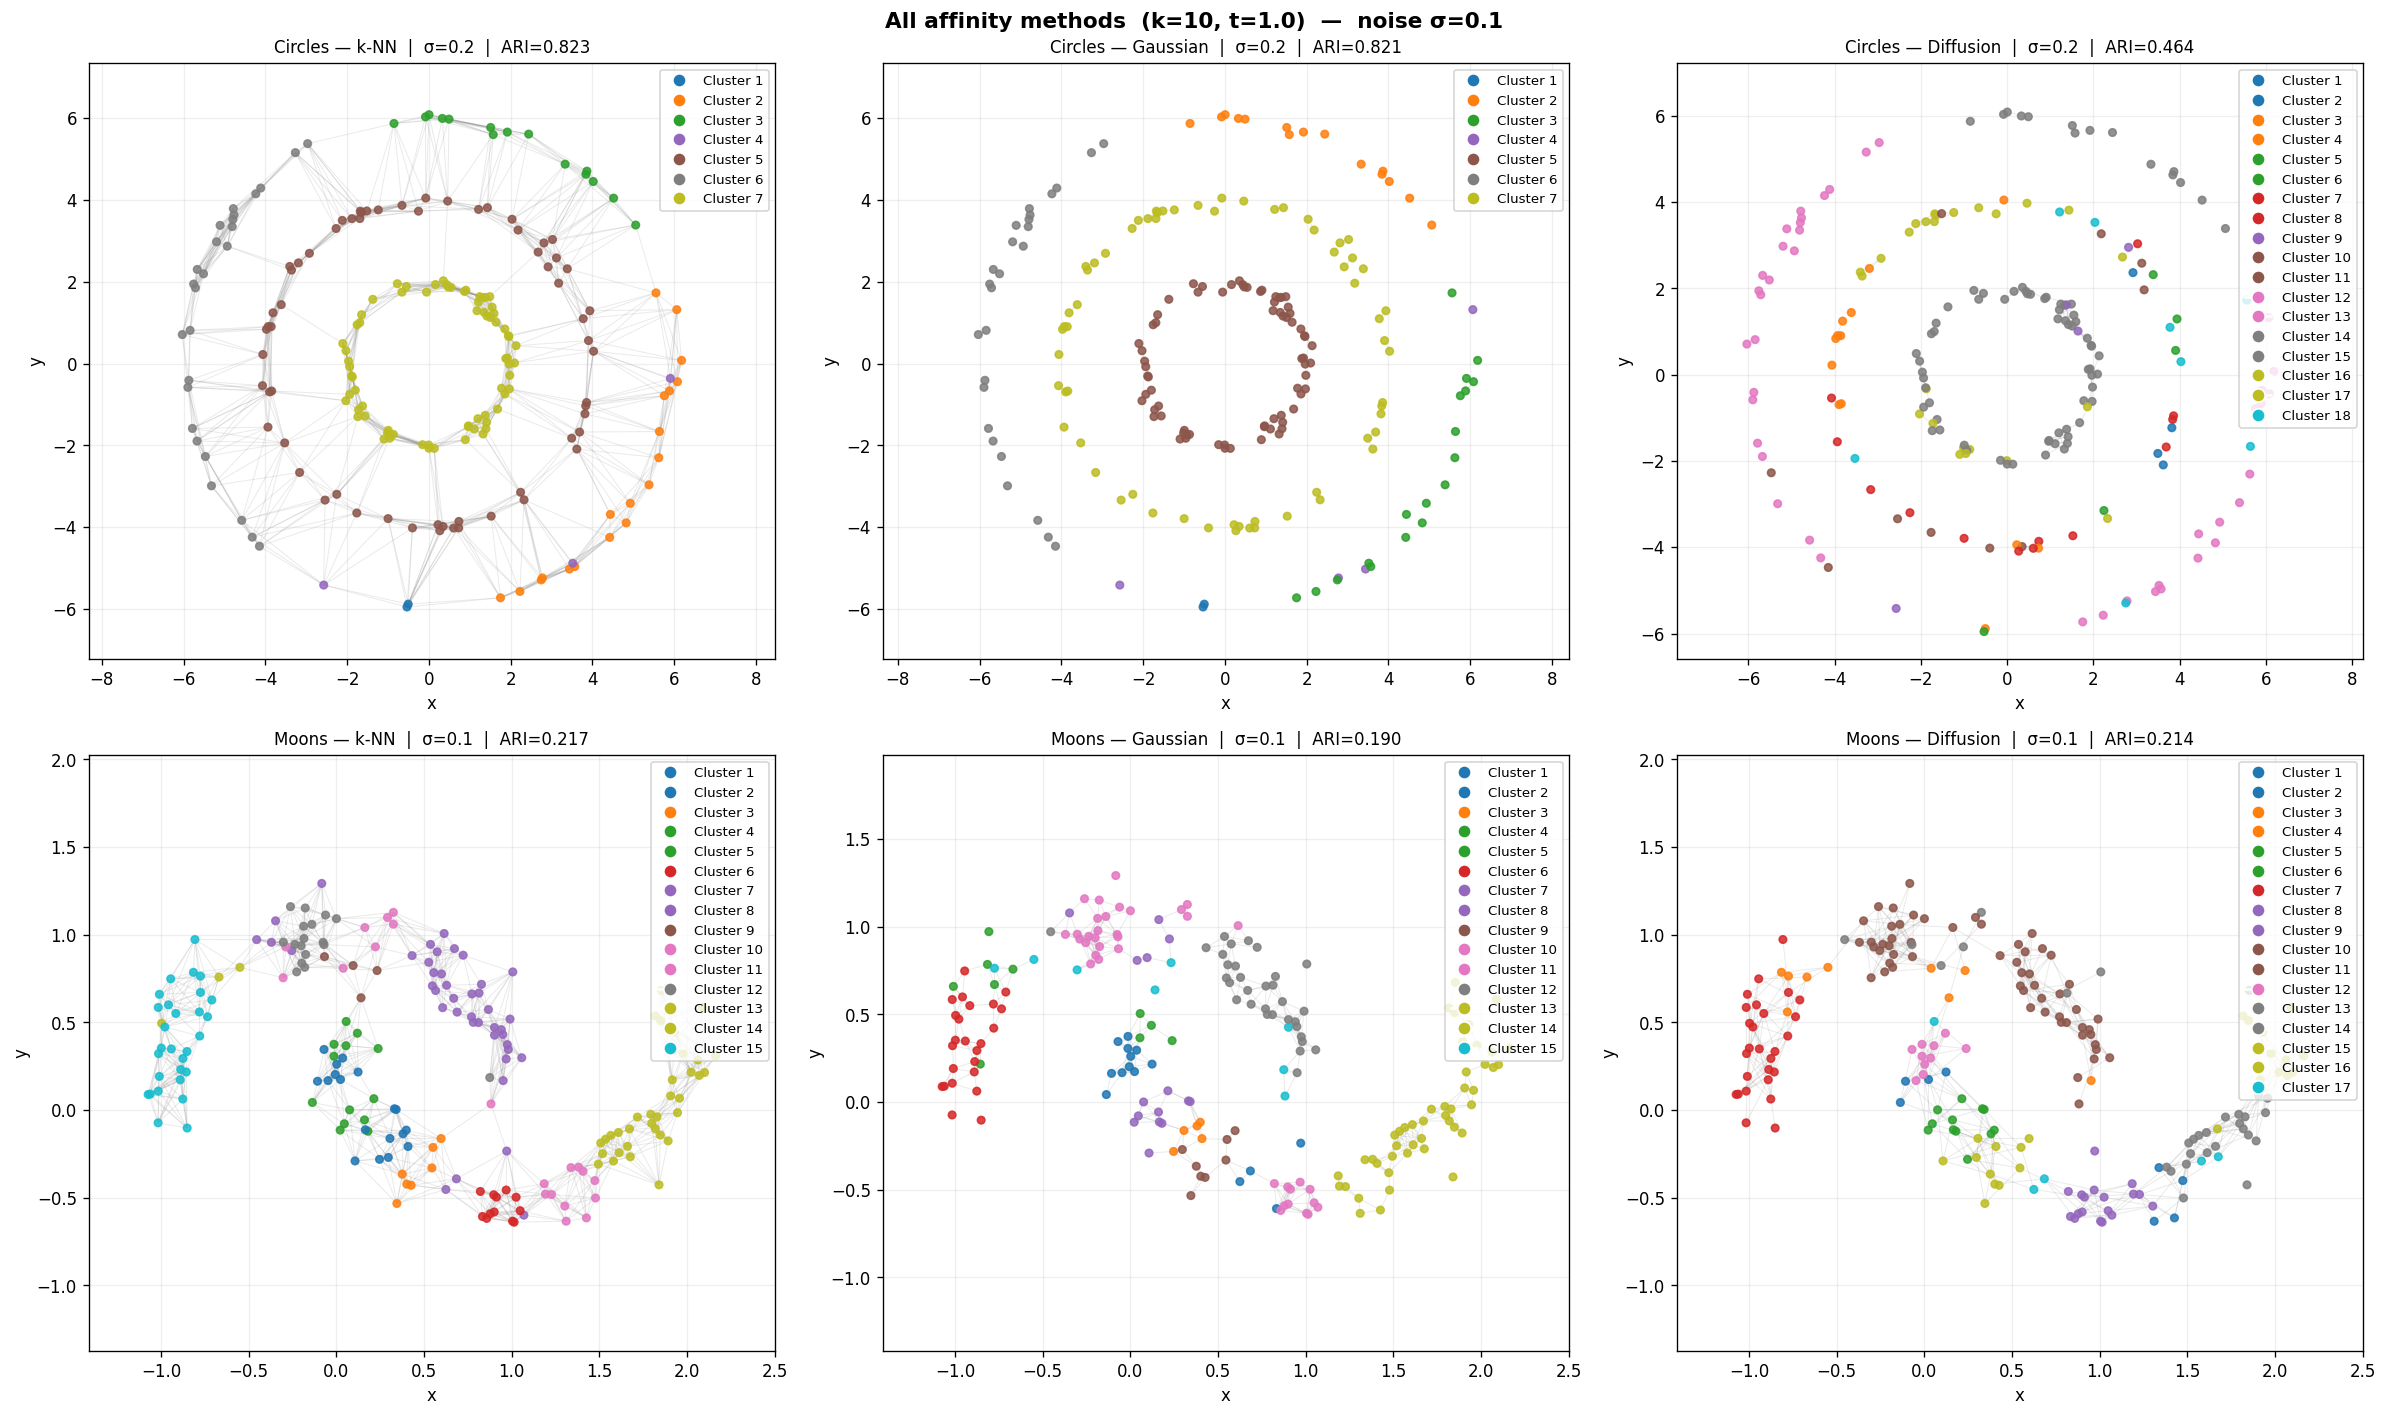

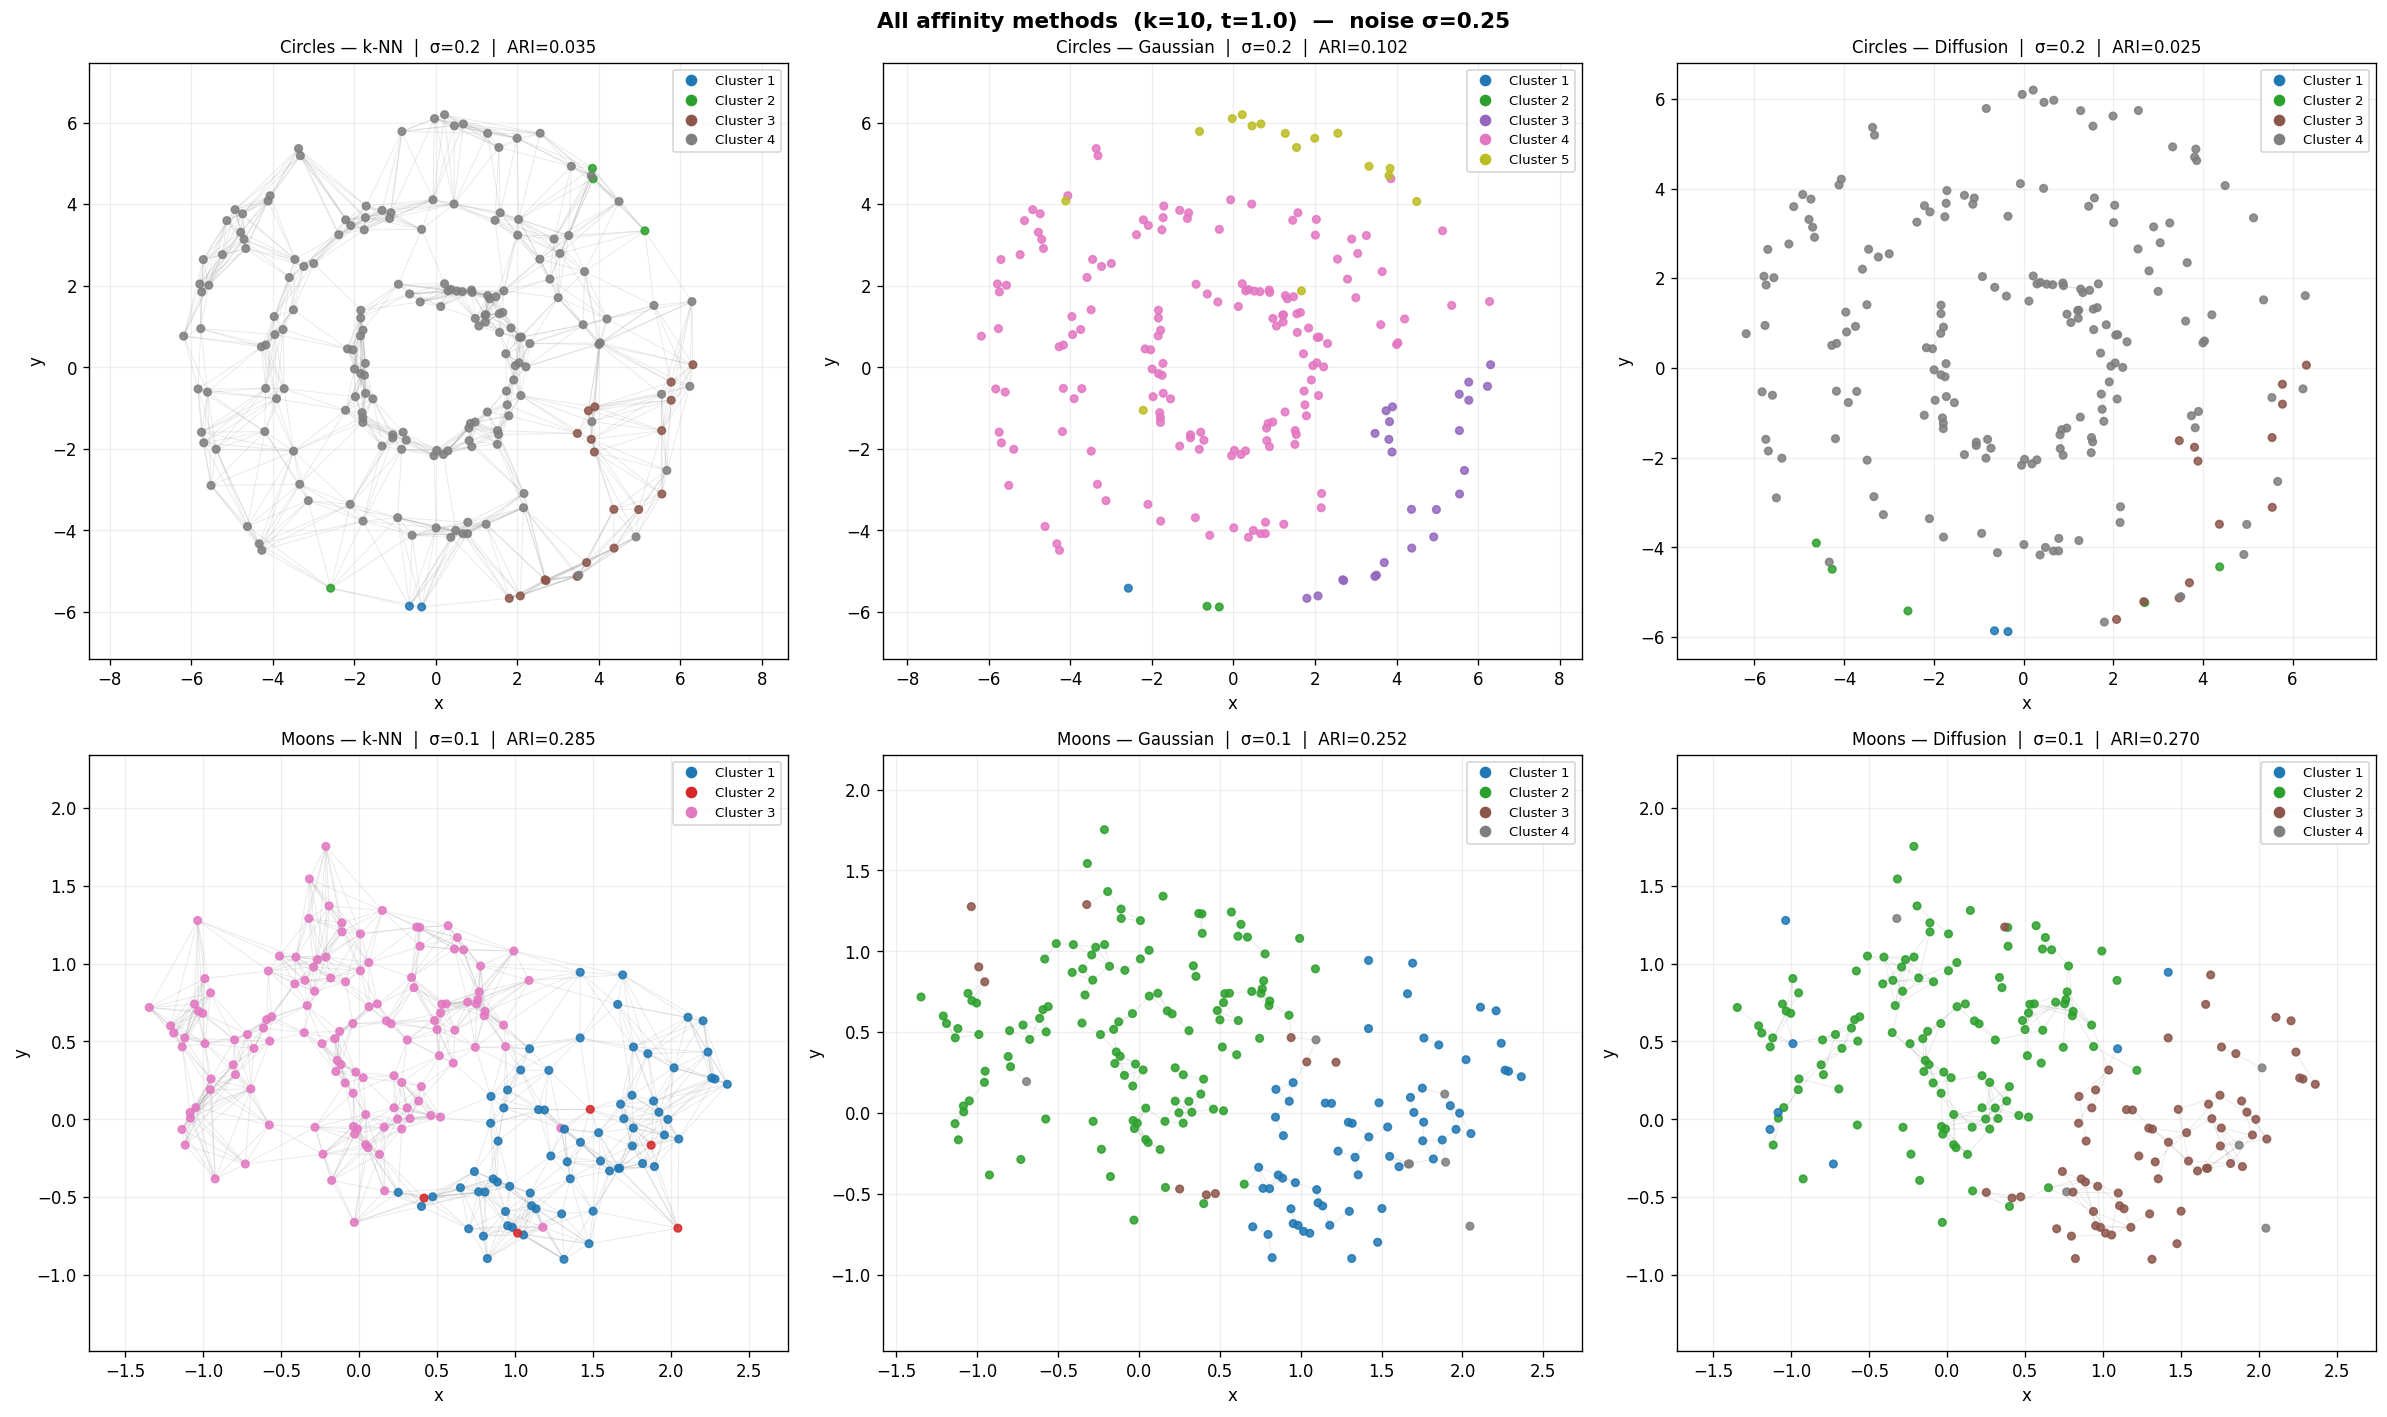

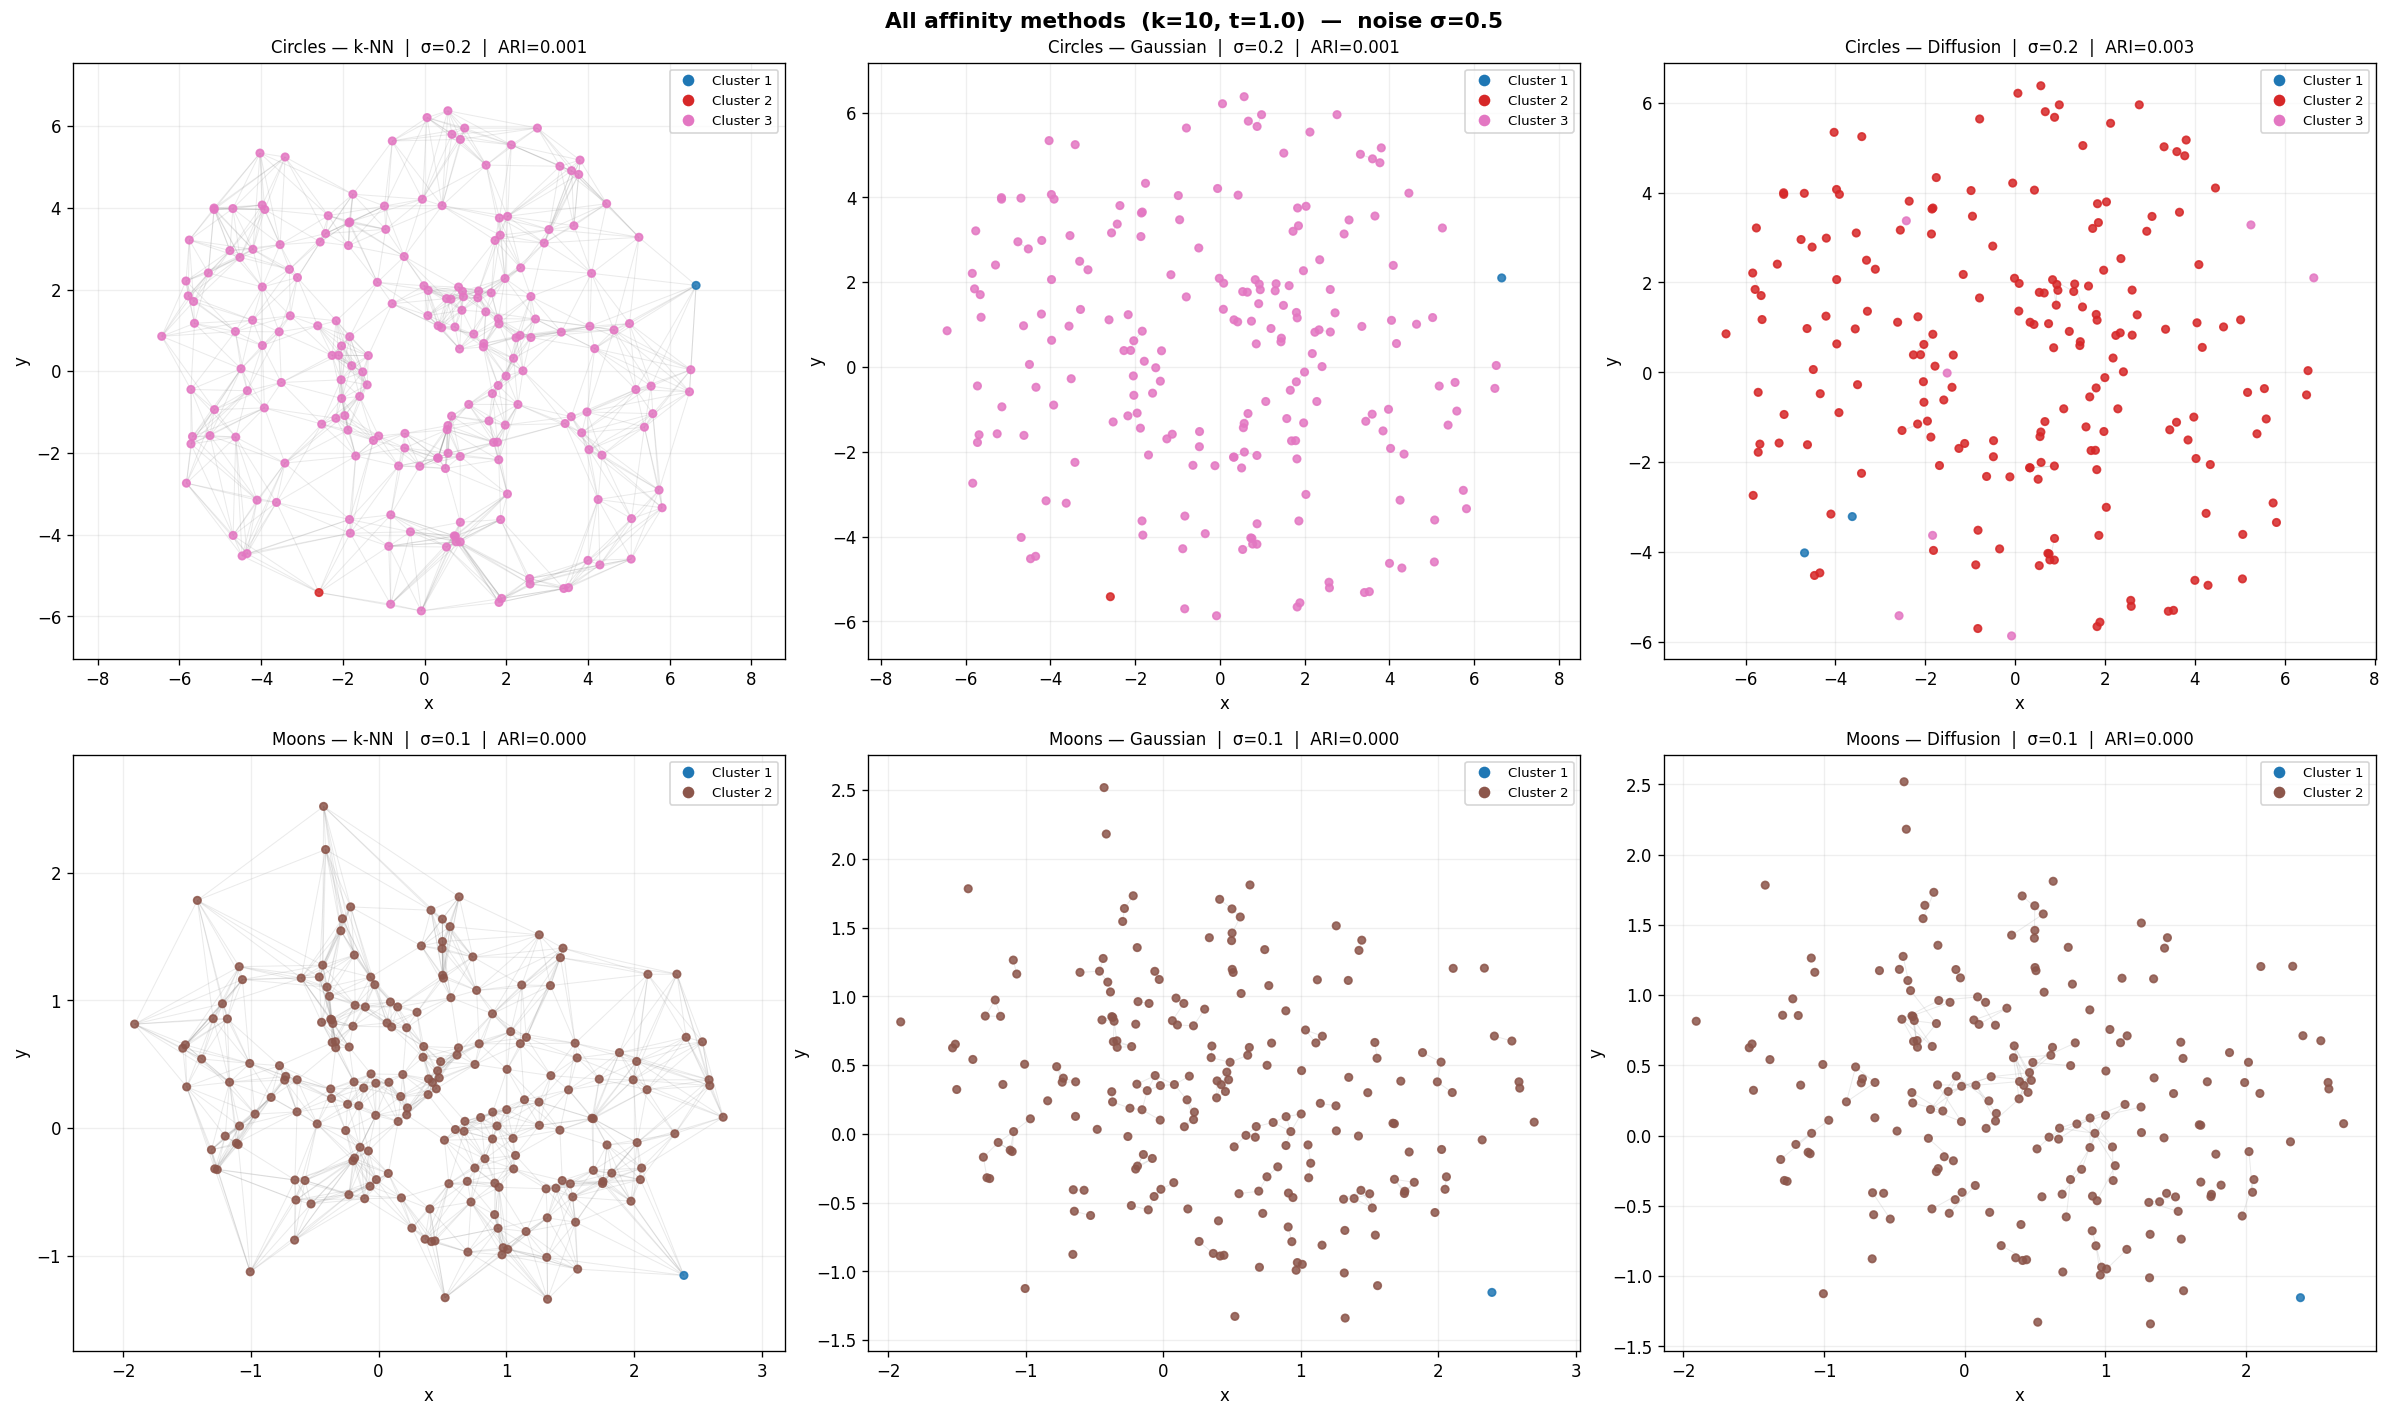

In [18]:
K, T = 10, 1.0

affinity_configs_noisy = [
    ("k-NN",      lambda D, s: affinity_knn(D, K, s),          0.00),
    ("Gaussian",  lambda D, s: affinity_gaussian(D, s),         0.30),
    ("Diffusion", lambda D, s: affinity_diffusion(D, K, s, T),  0.01),
]

for noise_std in noise_levels_2d:
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(
        f"All affinity methods  (k={K}, t={T})  —  noise σ={noise_std}",
        fontsize=13, fontweight="bold",
    )

    for row, (ds_label, ds_name, sigma, r) in enumerate(viz_configs_noisy):
        v = noisy_viz[(ds_name, noise_std)]
        for col, (aff_name, aff_fn, thresh) in enumerate(affinity_configs_noisy):
            ax     = axes[row, col]
            A      = aff_fn(v["D"], sigma)
            result = run_single(A, "sym", r, v["y"])

            plot_affinity_graph(
                v["X"], result["labels"], A,
                threshold=thresh,
                title=f"{ds_label} — {aff_name}  |  σ={sigma}  |  ARI={result['ari']:.3f}",
                ax=ax, node_size=20, edge_alpha=0.15,
            )

    plt.tight_layout()
    plt.show()

### 12b-c — Noise-level progression per affinity type

Each figure covers one affinity method across all three noise levels (columns) and both datasets (rows). Shows how the graph structure and ALC clustering quality degrade as noise increases.

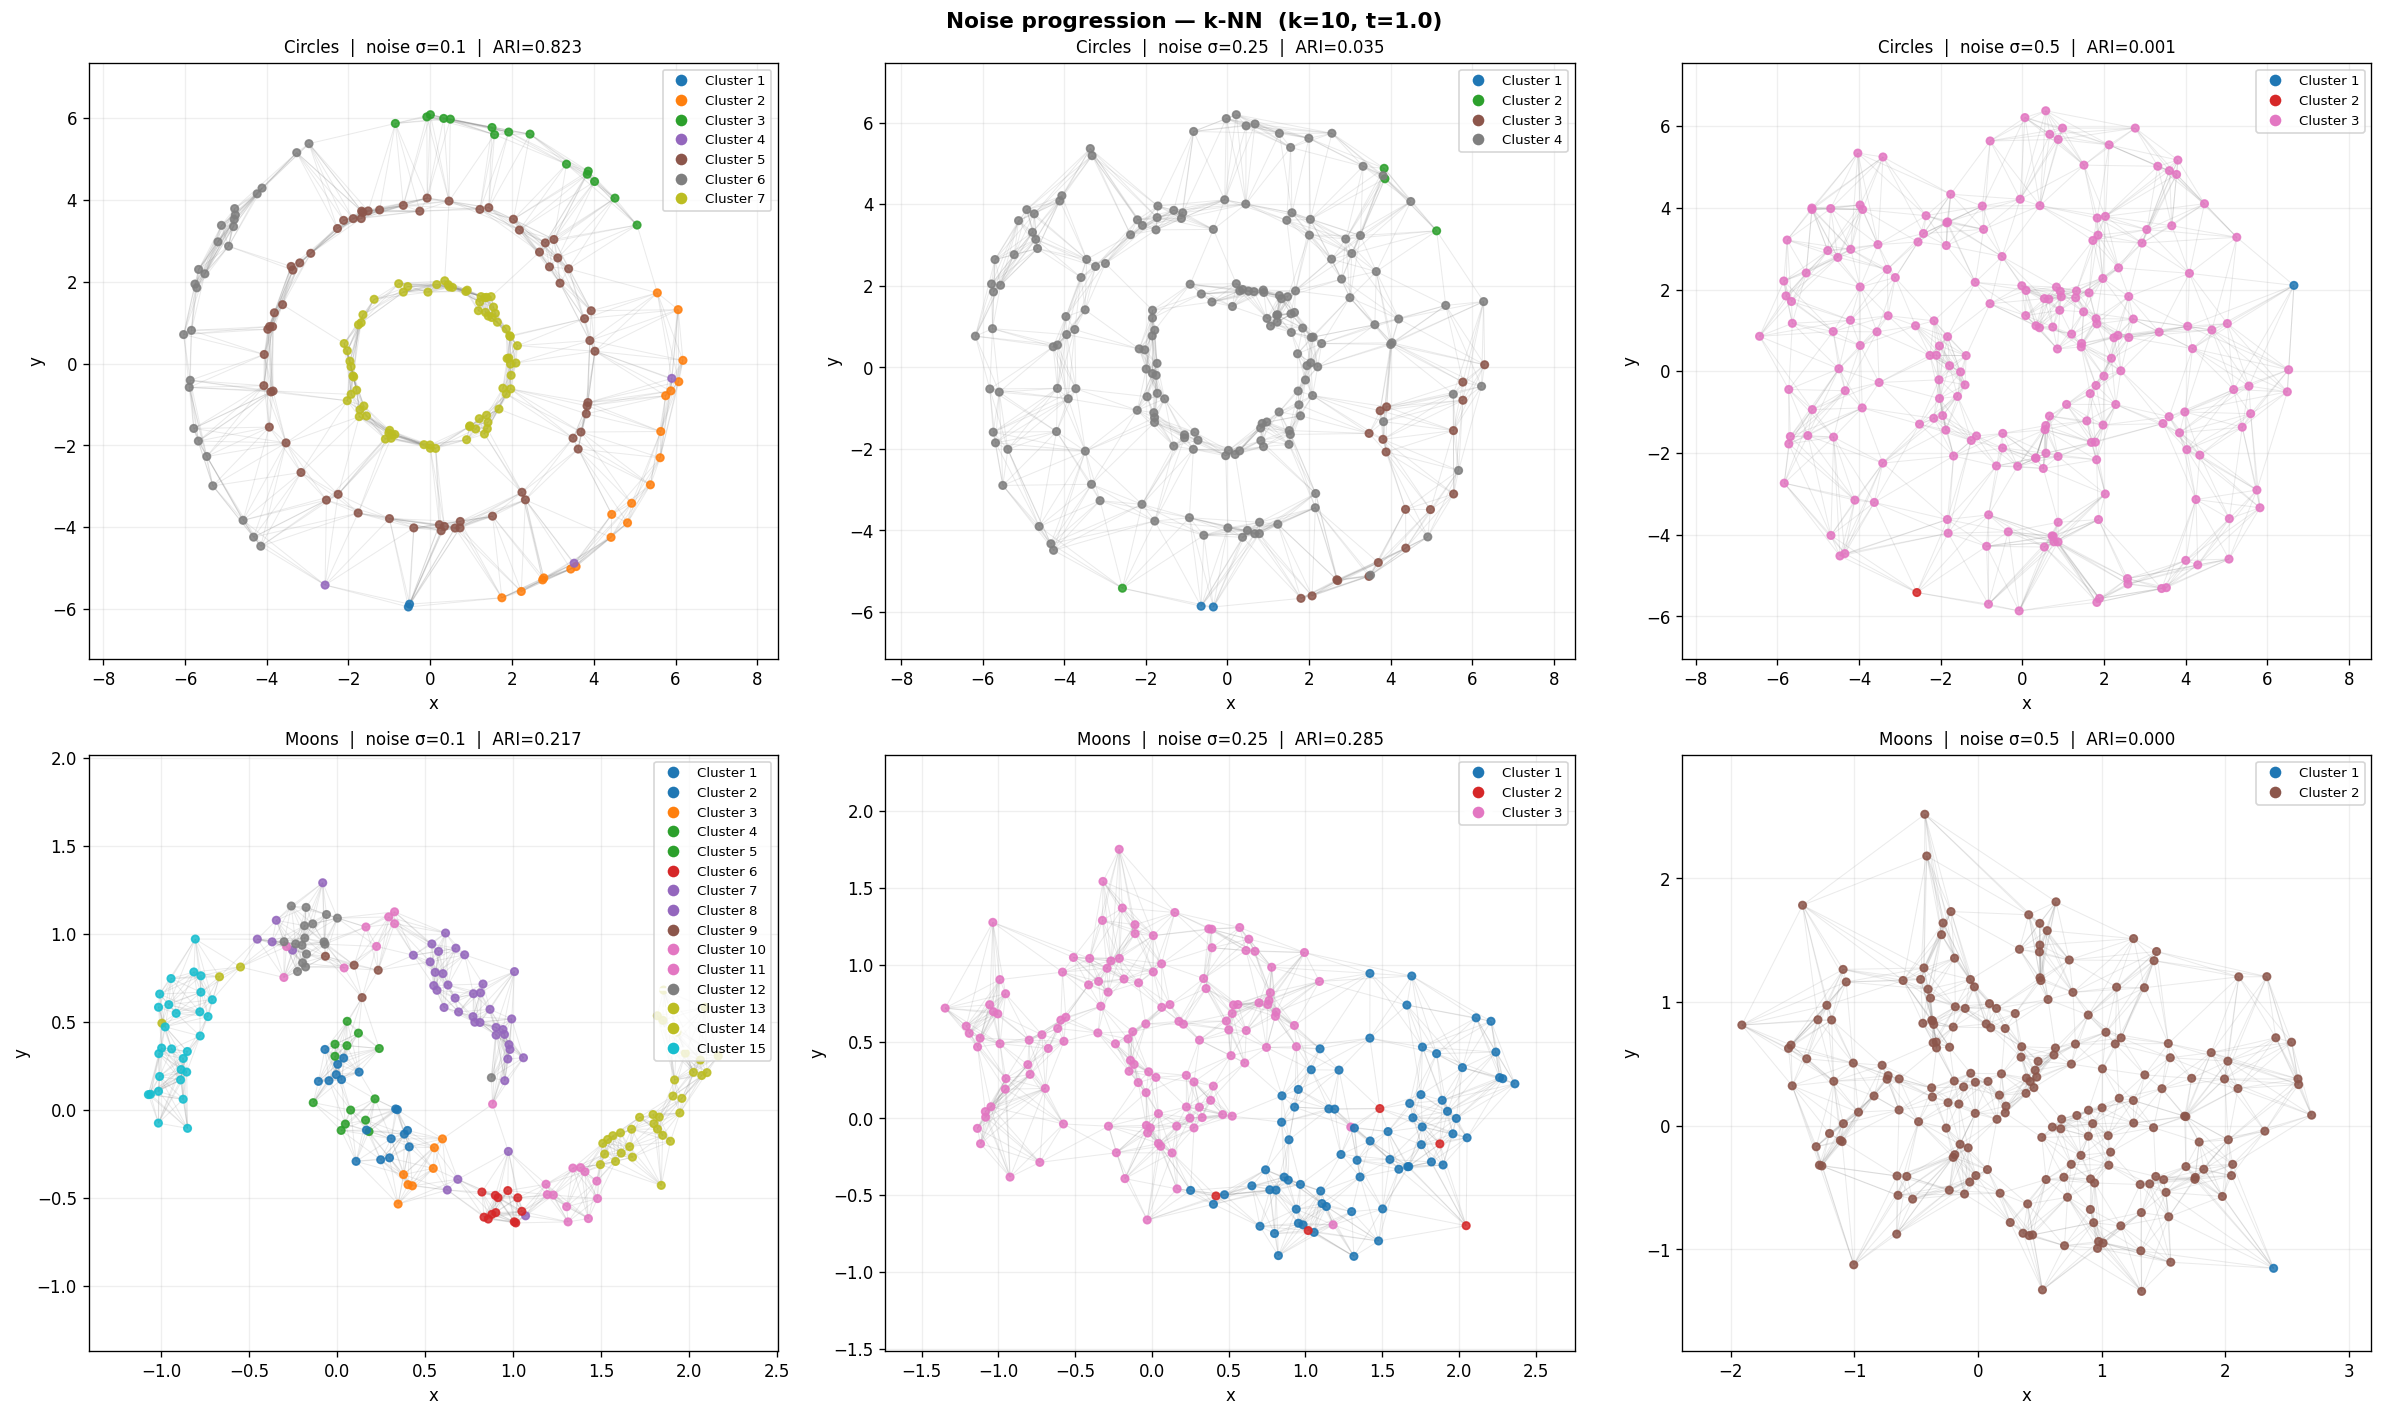

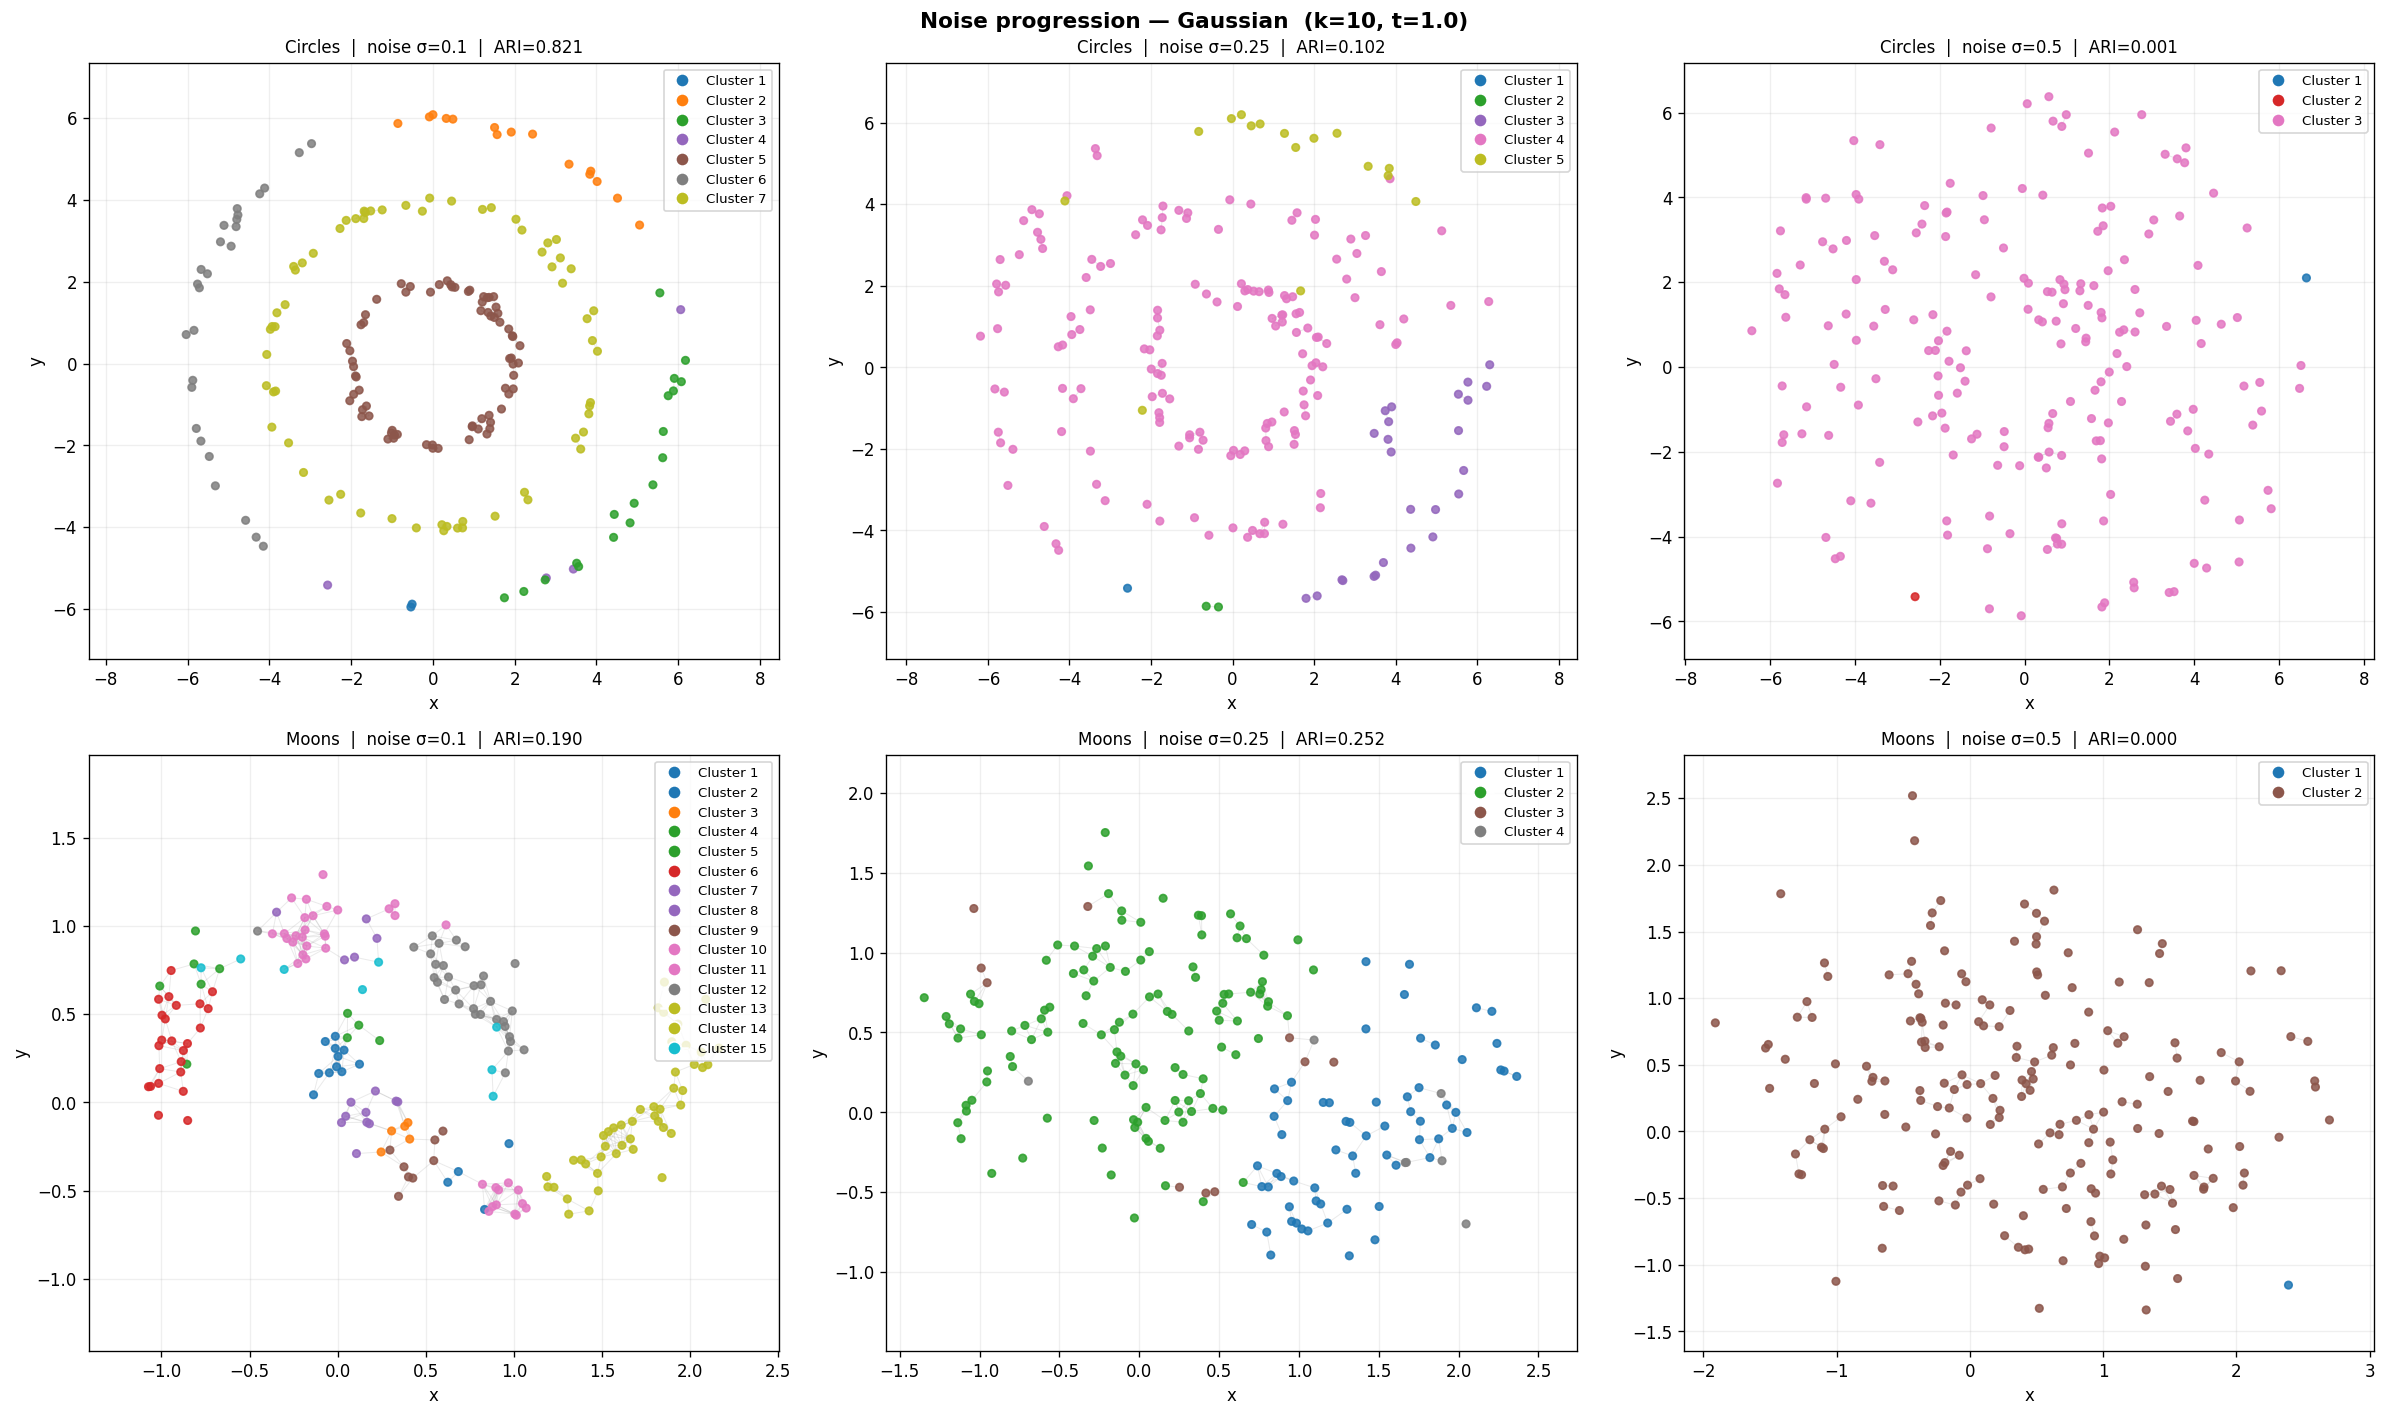

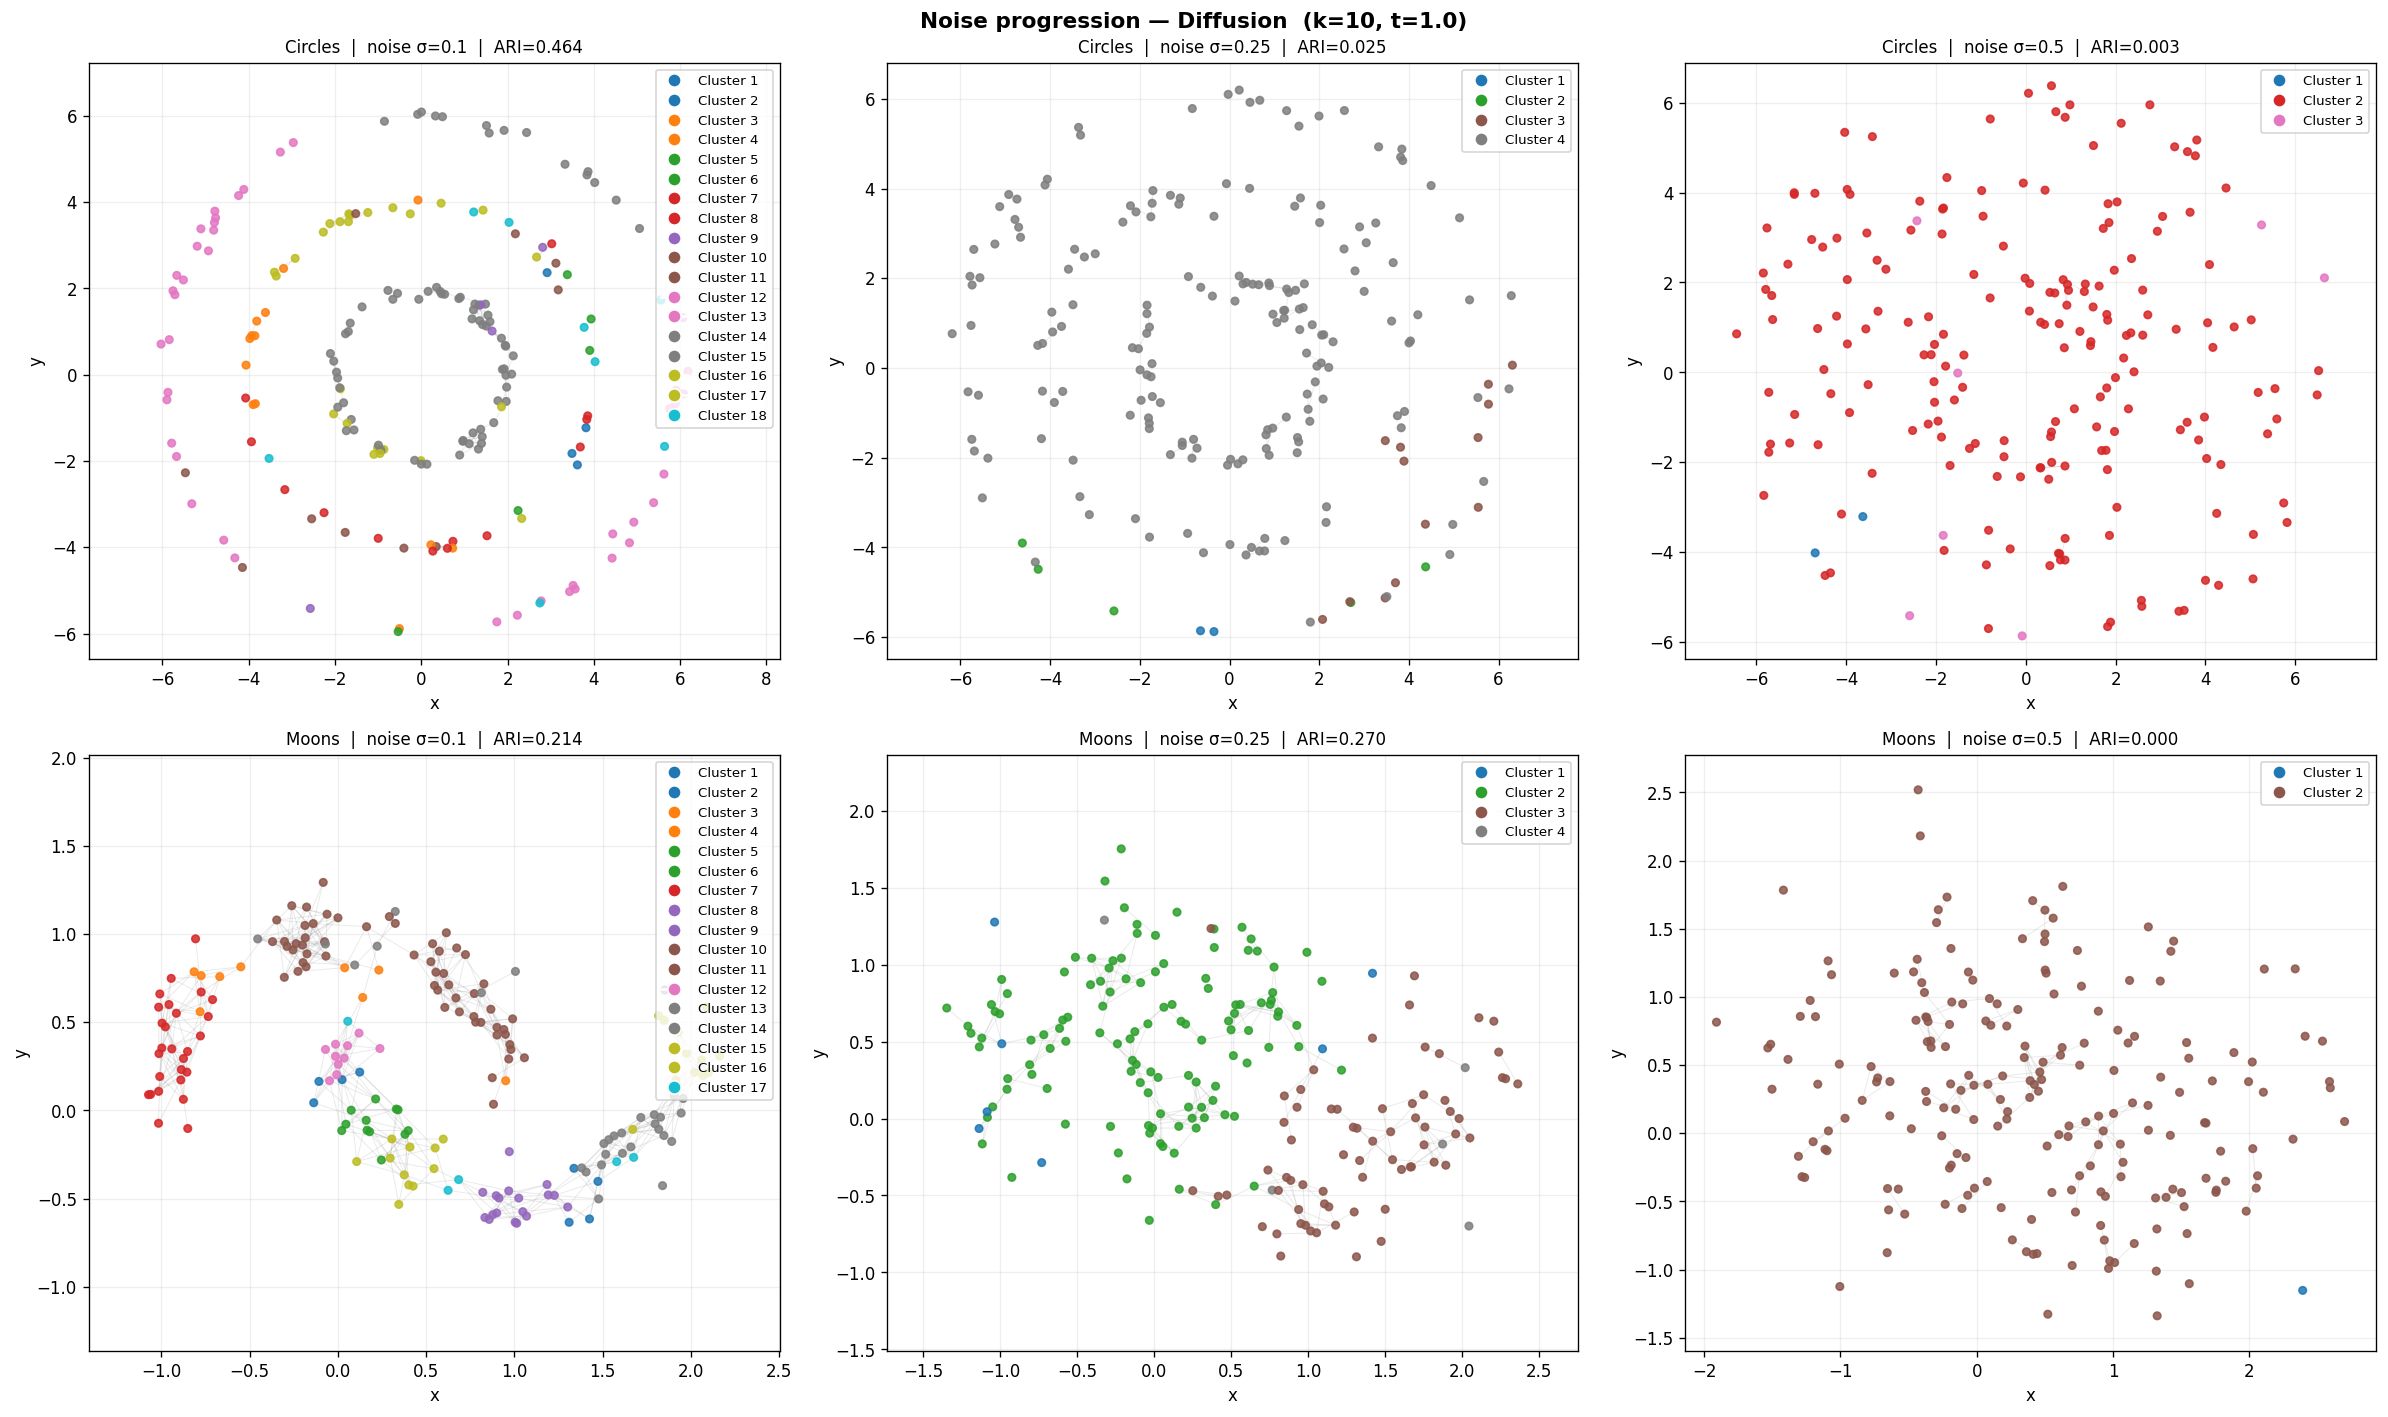

In [19]:
K, T = 10, 1.0

for aff_name, aff_fn, thresh in affinity_configs_noisy:
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(
        f"Noise progression — {aff_name}  (k={K}, t={T})",
        fontsize=13, fontweight="bold",
    )

    for row, (ds_label, ds_name, sigma, r) in enumerate(viz_configs_noisy):
        for col, noise_std in enumerate(noise_levels_2d):
            ax = axes[row, col]
            v  = noisy_viz[(ds_name, noise_std)]
            A  = aff_fn(v["D"], sigma)
            result = run_single(A, "sym", r, v["y"])

            plot_affinity_graph(
                v["X"], result["labels"], A,
                threshold=thresh,
                title=f"{ds_label}  |  noise σ={noise_std}  |  ARI={result['ari']:.3f}",
                ax=ax, node_size=20, edge_alpha=0.15,
            )

    plt.tight_layout()
    plt.show()